In [ ]:
!pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn rasterio --quiet


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
import warnings
import os
import glob
import gc
import json

In [ ]:
# !pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn rasterio --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
import warnings
import os
import glob
import gc
import json

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score,
    f1_score
)



In [ ]:
# Try importing rasterio
try:
    import rasterio
    from rasterio.plot import show
    RASTERIO_AVAILABLE = True
except ImportError:
    RASTERIO_AVAILABLE = False
    print("Warning: 'rasterio' not found. Spatial map generation will be skipped.")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
shap.initjs()

print("All dependencies loaded successfully.")

All dependencies loaded successfully.


#  Global Configurations and & Helper Functions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = '/content/drive/MyDrive/XAI_LULC_Ghana/'
if not os.path.exists(DATA_DIR):
    DATA_DIR = r'c:\YERBO\Desktop\CODING\EXPLAINABLE AI\\'

DATA_PATH_2020 = os.path.join(DATA_DIR, 'XAI_LULC_GAMA_Training_2020.csv')
DATA_PATH_2022 = os.path.join(DATA_DIR, 'XAI_LULC_GAMA_Training_2022.csv')
DATA_PATH_2024 = os.path.join(DATA_DIR, 'XAI_LULC_GAMA_Training_2024_NEW.csv')
if not os.path.exists(DATA_PATH_2024):
    DATA_PATH_2024 = os.path.join(DATA_DIR, 'XAI TRAINING DATASET.csv')


In [ ]:
df_2020 = pd.read_csv(DATA_PATH_2020) if os.path.exists(DATA_PATH_2020) else None
df_2022 = pd.read_csv(DATA_PATH_2022) if os.path.exists(DATA_PATH_2022) else None
df_2024 = pd.read_csv(DATA_PATH_2024) if os.path.exists(DATA_PATH_2024) else None

In [ ]:
for year, df in [(2020, df_2020), (2022, df_2022), (2024, df_2024)]:
    if df is not None:
        print(f"\n[{year}] Dataset shape: {df.shape}")
        print(f"[{year}] Columns ({len(df.columns)}): {list(df.columns)}")
        print(df.head(2))
        print("-"*50)


[2020] Dataset shape: (1600, 28)
[2020] Columns (28): ['system:index', 'Aspect', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'BSI', 'EVI', 'Elevation', 'GLCM_ASM', 'GLCM_Contrast', 'GLCM_Correlation', 'GLCM_Entropy', 'GLCM_Homogeneity', 'MNDWI', 'NDBI', 'NDVI', 'NDWI', 'SAVI', 'Slope', 'class', '.geo']
   system:index     Aspect     B11      B12       B2      B3      B4       B5  \
0             0  63.547960  0.3125  0.28755  0.06425  0.0992  0.1461  0.18885   
1             1  45.138813  0.3251  0.31220  0.09060  0.1230  0.1648  0.20220   

       B6       B7  ...  GLCM_Entropy  GLCM_Homogeneity     MNDWI      NDBI  \
0  0.2147  0.22885  ...      4.353742          0.002332 -0.518096  0.138641   
1  0.2029  0.20590  ...      4.335863          0.026464 -0.451015  0.238712   

       NDVI      NDWI      SAVI     Slope  class  \
0  0.236078 -0.408820  0.153484  2.081235      1   
1  0.095996 -0.237918  0.060722  1.314629      1   

                                     

In [ ]:
# --- 3A. Automatically identify Label Column & Clean GEE metadata ---
LABEL_COLS = {}
for year, df in [(2020, df_2020), (2022, df_2022), (2024, df_2024)]:
    if df is not None:
        label_col = None
        for col in ['class', 'LULC_CLASS']:
            if col in df.columns:
                label_col = col
                break
        if label_col is None:
            label_col = df.columns[-1]
            print(f"Warning: Target not found for {year}. Using '{label_col}'.")
        LABEL_COLS[year] = label_col

        # Drop GEE system metadata columns if present
        metadata_cols = ['system:index', '.geo']
        for col in metadata_cols:
            if col in df.columns:
                df = df.drop(columns=[col])
                if year == 2020: df_2020 = df
                elif year == 2022: df_2022 = df
                elif year == 2024: df_2024 = df
                print(f"[{year}] Dropped metadata column: {col}")

[2020] Dropped metadata column: system:index
[2020] Dropped metadata column: .geo
[2022] Dropped metadata column: system:index
[2022] Dropped metadata column: .geo
[2024] Dropped metadata column: system:index
[2024] Dropped metadata column: .geo


In [ ]:
CLASS_NAMES = {
    1: 'Built-Up',
    2: 'Vegetation',
    3: 'Water',
    4: 'Bare Soil'
}

CLASS_COLORS = {
    1: '#E8453C',   # Built-Up (red)
    2: '#1B7A2F',   # Vegetation (dark green)
    3: '#2196F3',   # Water (blue)
    4: '#9E9E9E'    # Bare Soil (grey)
}

In [ ]:
# Feature columns — everything except the label and class mapping helper
FEATURE_COLS_MAP = {}
for year, df in [(2020, df_2020), (2022, df_2022), (2024, df_2024)]:
    if df is not None:
        label_col = LABEL_COLS[year]
        FEATURE_COLS_MAP[year] = [col for col in df.columns if col not in [label_col, 'label_0idx']]
        print(f"\n--- {year} Label Column Detected: '{label_col}' ---")
        print(f"--- {year} Feature Columns ({len(FEATURE_COLS_MAP[year])}) ---")
        for i, col in enumerate(FEATURE_COLS_MAP[year], 1):
            print(f"  {i:2d}. {col}")


--- 2020 Label Column Detected: 'class' ---
--- 2020 Feature Columns (25) ---
   1. Aspect
   2. B11
   3. B12
   4. B2
   5. B3
   6. B4
   7. B5
   8. B6
   9. B7
  10. B8
  11. B8A
  12. BSI
  13. EVI
  14. Elevation
  15. GLCM_ASM
  16. GLCM_Contrast
  17. GLCM_Correlation
  18. GLCM_Entropy
  19. GLCM_Homogeneity
  20. MNDWI
  21. NDBI
  22. NDVI
  23. NDWI
  24. SAVI
  25. Slope

--- 2022 Label Column Detected: 'class' ---
--- 2022 Feature Columns (25) ---
   1. Aspect
   2. B11
   3. B12
   4. B2
   5. B3
   6. B4
   7. B5
   8. B6
   9. B7
  10. B8
  11. B8A
  12. BSI
  13. EVI
  14. Elevation
  15. GLCM_ASM
  16. GLCM_Contrast
  17. GLCM_Correlation
  18. GLCM_Entropy
  19. GLCM_Homogeneity
  20. MNDWI
  21. NDBI
  22. NDVI
  23. NDWI
  24. SAVI
  25. Slope

--- 2024 Label Column Detected: 'class' ---
--- 2024 Feature Columns (25) ---
   1. Aspect
   2. B11
   3. B12
   4. B2
   5. B3
   6. B4
   7. B5
   8. B6
   9. B7
  10. B8
  11. B8A
  12. BSI
  13. EVI
  14. Elevation
 

In [ ]:
# --- 3B. Class distribution ---
CLASS_COUNTS_MAP = {}
for year, df in [(2020, df_2020), (2022, df_2022), (2024, df_2024)]:
    if df is not None:
        label_col = LABEL_COLS[year]
        print(f"\n--- Class Distribution ({year}) ---")
        counts = df[label_col].value_counts().sort_index()
        CLASS_COUNTS_MAP[year] = counts
        for cls_id, count in counts.items():
            print(f"  Class {cls_id} ({CLASS_NAMES[cls_id]}): {count} samples")
        print(f"  TOTAL: {counts.sum()} samples")


--- Class Distribution (2020) ---
  Class 1 (Built-Up): 400 samples
  Class 2 (Vegetation): 400 samples
  Class 3 (Water): 400 samples
  Class 4 (Bare Soil): 400 samples
  TOTAL: 1600 samples

--- Class Distribution (2022) ---
  Class 1 (Built-Up): 400 samples
  Class 2 (Vegetation): 400 samples
  Class 3 (Water): 400 samples
  Class 4 (Bare Soil): 400 samples
  TOTAL: 1600 samples

--- Class Distribution (2024) ---
  Class 1 (Built-Up): 400 samples
  Class 2 (Vegetation): 400 samples
  Class 3 (Water): 400 samples
  Class 4 (Bare Soil): 400 samples
  TOTAL: 1600 samples


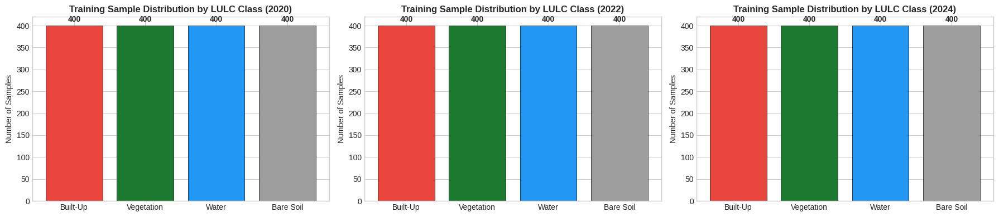

In [ ]:
valid_years = [y for y in [2020, 2022, 2024] if y in CLASS_COUNTS_MAP]
fig, axes = plt.subplots(1, len(valid_years), figsize=(6 * len(valid_years), 4))
if len(valid_years) == 1:
    axes = [axes]
for idx, year in enumerate(valid_years):
    counts = CLASS_COUNTS_MAP[year]
    ax = axes[idx]
    bars = ax.bar(
        [CLASS_NAMES[i] for i in counts.index],
        counts.values,
        color=[CLASS_COLORS[i] for i in counts.index],
        edgecolor='black', linewidth=0.5
    )
    ax.set_title(f'Training Sample Distribution by LULC Class ({year})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Samples')
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- 3C. Handle missing values ---
for year, df in [(2020, df_2020), (2022, df_2022), (2024, df_2024)]:
    if df is not None:
        feats = FEATURE_COLS_MAP[year]
        print(f"\n[{year}] Missing values: {df[feats].isnull().sum().sum()}")
        df = df.dropna(subset=feats)
        if year == 2020: df_2020 = df
        elif year == 2022: df_2022 = df
        elif year == 2024: df_2024 = df
        print(f"[{year}] Samples after cleaning: {len(df)}")


[2020] Missing values: 0
[2020] Samples after cleaning: 1600

[2022] Missing values: 0
[2022] Samples after cleaning: 1600

[2024] Missing values: 0
[2024] Samples after cleaning: 1600


In [ ]:
# --- 3D. Remap classes to 0-indexed (required by XGBoost) ---
for year, df in [(2020, df_2020), (2022, df_2022), (2024, df_2024)]:
    if df is not None:
        label_col = LABEL_COLS[year]
        df['label_0idx'] = df[label_col] - 1
        if year == 2020: df_2020 = df
        elif year == 2022: df_2022 = df
        elif year == 2024: df_2024 = df
        num_classes = df['label_0idx'].nunique()
        print(f"\n[{year}] Remapped classes to 0-indexed: {sorted(df['label_0idx'].unique())}")
        print(f"[{year}] Number of classes: {num_classes}")


[2020] Remapped classes to 0-indexed: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
[2020] Number of classes: 4

[2022] Remapped classes to 0-indexed: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
[2022] Number of classes: 4

[2024] Remapped classes to 0-indexed: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
[2024] Number of classes: 4


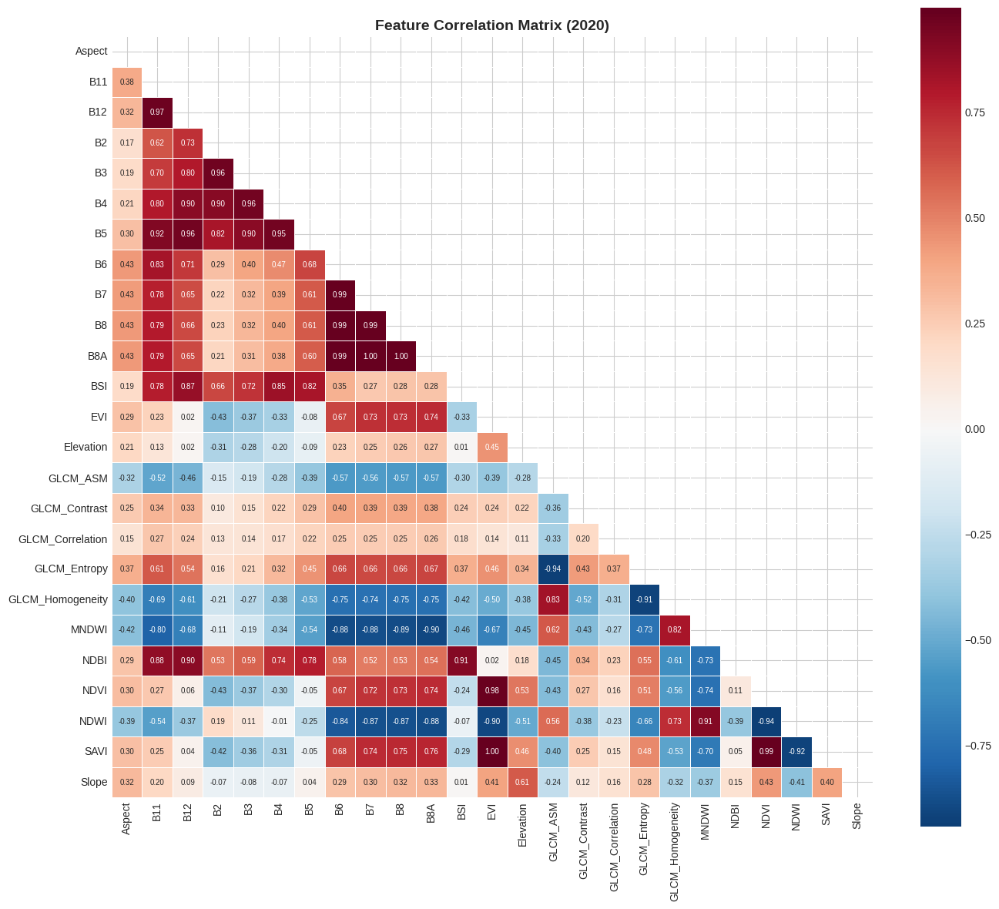

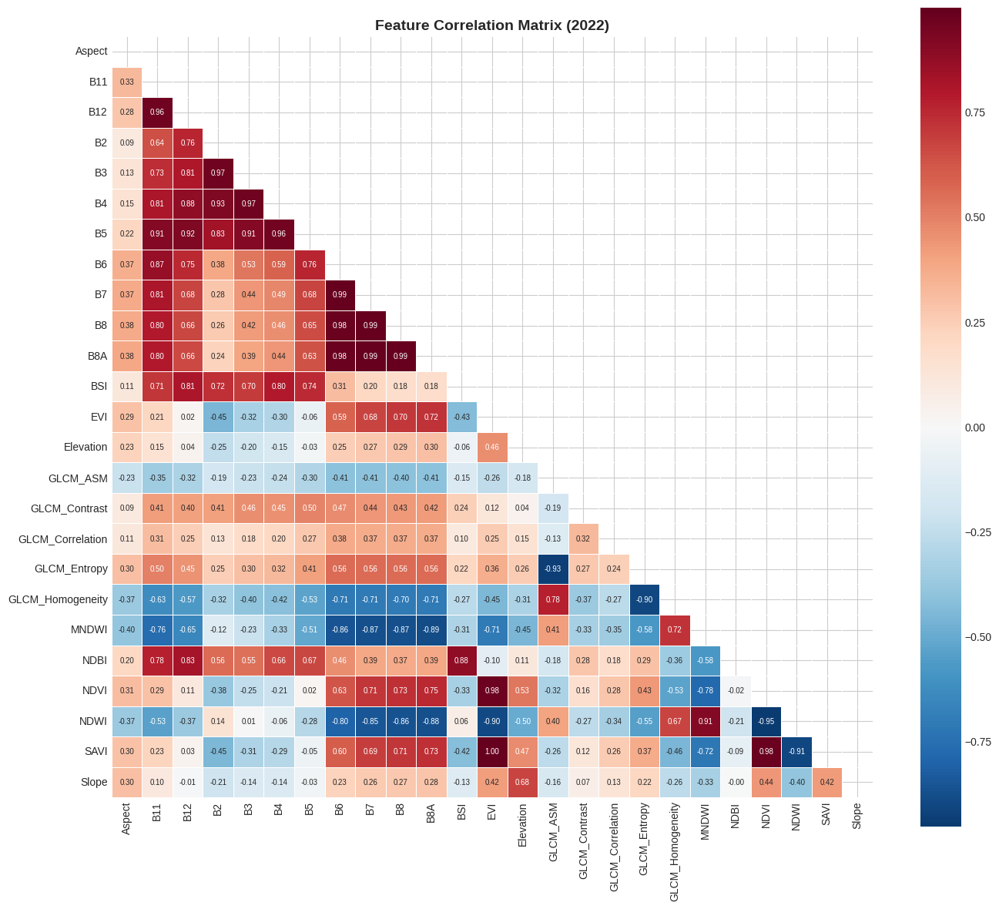

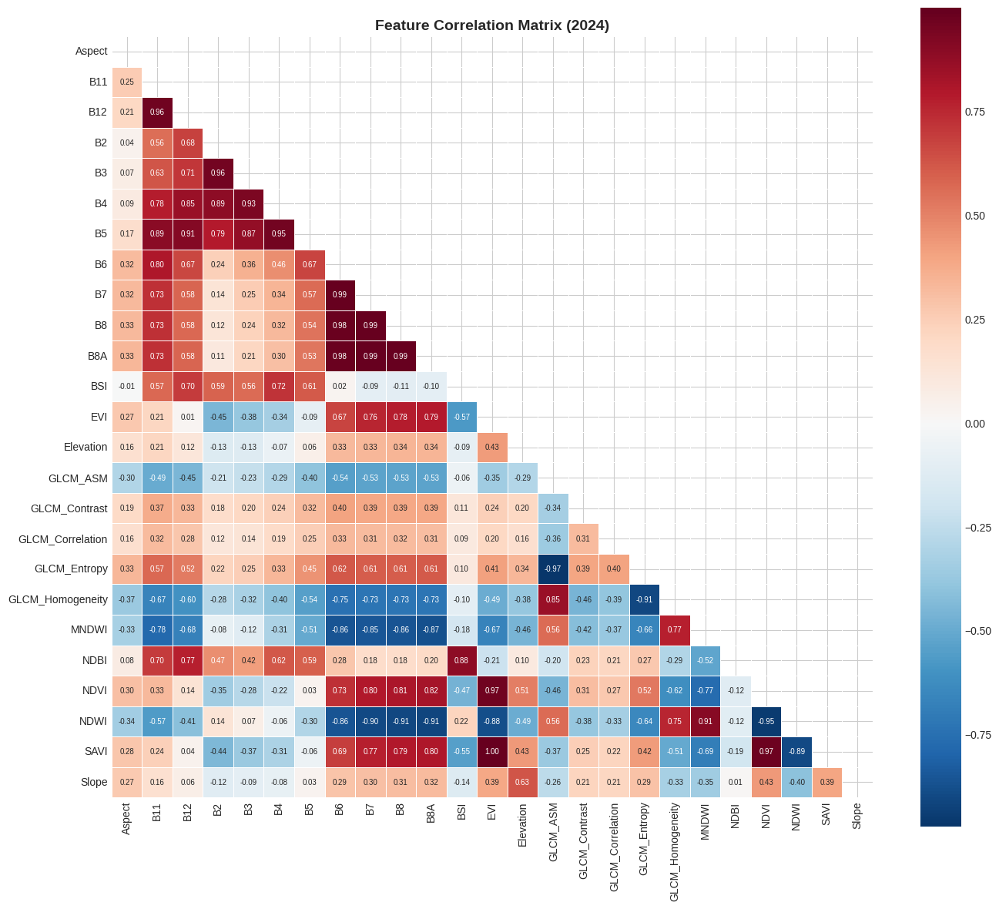

In [ ]:
# Check for highly correlated features
for year, df in [(2020, df_2020), (2022, df_2022), (2024, df_2024)]:
    if df is not None:
        feats = FEATURE_COLS_MAP[year]
        corr_matrix = df[feats].corr()

        fig, ax = plt.subplots(figsize=(14, 12))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, square=True, linewidths=0.5, ax=ax,
                    annot_kws={'size': 7})
        ax.set_title(f'Feature Correlation Matrix ({year})', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'feature_correlation_{year}.png', dpi=150, bbox_inches='tight')
        plt.show()

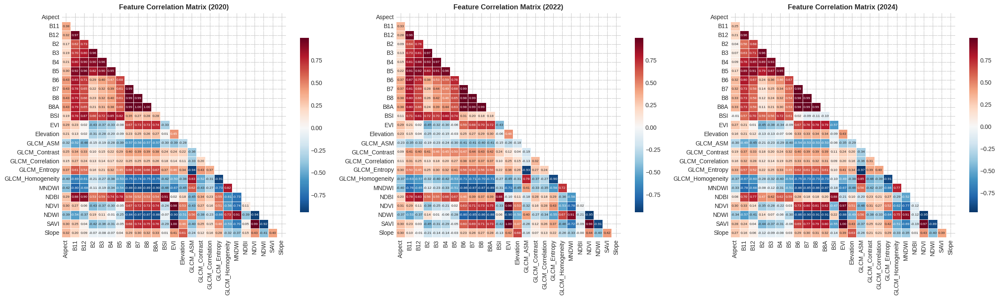

In [ ]:
# Check for highly correlated features (Side-by-Side Plots)
valid_years = [y for y in [2020, 2022, 2024] if (
    (y == 2020 and df_2020 is not None) or
    (y == 2022 and df_2022 is not None) or
    (y == 2024 and df_2024 is not None)
)]

if valid_years:
    fig, axes = plt.subplots(1, len(valid_years), figsize=(8 * len(valid_years), 7))
    if len(valid_years) == 1:
        axes = [axes]

    for idx, year in enumerate(valid_years):
        df = df_2020 if year == 2020 else (df_2022 if year == 2022 else df_2024)
        ax = axes[idx]
        feats = FEATURE_COLS_MAP[year]
        corr_matrix = df[feats].corr()

        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, square=True, linewidths=0.5, ax=ax,
                    annot_kws={'size': 6}, cbar_kws={'shrink': 0.7})
        ax.set_title(f'Feature Correlation Matrix ({year})', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('feature_correlation_side_by_side.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# Flag highly correlated pairs (|r| > 0.95)
for year, df in [(2020, df_2020), (2022, df_2022), (2024, df_2024)]:
    if df is not None:
        feats = FEATURE_COLS_MAP[year]
        corr_matrix = df[feats].corr()
        high_corr = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > 0.95:
                    high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
        if high_corr:
            print(f"\n⚠ Highly correlated feature pairs (|r| > 0.95) for {year}:")
            for f1, f2, r in high_corr:
                print(f"  {f1} ↔ {f2}: r = {r:.4f}")
        else:
            print(f"\n✓ No feature pairs with |r| > 0.95 found for {year}.")


⚠ Highly correlated feature pairs (|r| > 0.95) for 2020:
  B11 ↔ B12: r = 0.9687
  B12 ↔ B5: r = 0.9558
  B2 ↔ B3: r = 0.9634
  B3 ↔ B4: r = 0.9556
  B4 ↔ B5: r = 0.9526
  B6 ↔ B7: r = 0.9942
  B6 ↔ B8: r = 0.9897
  B6 ↔ B8A: r = 0.9894
  B7 ↔ B8: r = 0.9943
  B7 ↔ B8A: r = 0.9955
  B8 ↔ B8A: r = 0.9956
  EVI ↔ NDVI: r = 0.9813
  EVI ↔ SAVI: r = 0.9978
  NDVI ↔ SAVI: r = 0.9869

⚠ Highly correlated feature pairs (|r| > 0.95) for 2022:
  B11 ↔ B12: r = 0.9639
  B2 ↔ B3: r = 0.9656
  B3 ↔ B4: r = 0.9655
  B4 ↔ B5: r = 0.9553
  B6 ↔ B7: r = 0.9910
  B6 ↔ B8: r = 0.9818
  B6 ↔ B8A: r = 0.9790
  B7 ↔ B8: r = 0.9938
  B7 ↔ B8A: r = 0.9941
  B8 ↔ B8A: r = 0.9944
  EVI ↔ NDVI: r = 0.9752
  EVI ↔ SAVI: r = 0.9987
  NDVI ↔ NDWI: r = -0.9521
  NDVI ↔ SAVI: r = 0.9778

⚠ Highly correlated feature pairs (|r| > 0.95) for 2024:
  B11 ↔ B12: r = 0.9646
  B2 ↔ B3: r = 0.9560
  B4 ↔ B5: r = 0.9539
  B6 ↔ B7: r = 0.9888
  B6 ↔ B8: r = 0.9787
  B6 ↔ B8A: r = 0.9764
  B7 ↔ B8: r = 0.9929
  B7 ↔ B8A: r = 0

In [ ]:
# --- Define redundant features to drop ---
COLS_TO_DROP = [
    'B2',         # Drop Blue (r = 0.9560 with Green B3) -> Keep B3
    'B5',         # Drop RedEdge-1 (r = 0.9539 with Red B4) -> Keep B4
    'B6',         # Drop RedEdge-2 (r = 0.9787 with NIR B8) -> Keep B8
    'B7',         # Drop RedEdge-3 (r = 0.9929 with NIR B8) -> Keep B8
    'B8A',        # Drop Narrow NIR (r = 0.9936 with NIR B8) -> Keep B8
    'B12',        # Drop SWIR-2 (r = 0.9646 with SWIR-1 B11) -> Keep B11
    'EVI',        # Drop EVI (r = 0.9670 with NDVI) -> Keep NDVI
    'SAVI',       # Drop SAVI (r = 0.9735 with NDVI) -> Keep NDVI
    'NDWI',       # Drop NDWI (r = -0.9520 with NDVI) -> Keep MNDWI (better for urban areas)
    'GLCM_ASM'    # Drop GLCM_ASM (r = -0.9708 with GLCM_Entropy) -> Keep GLCM_Entropy
]

# --- Filter FEATURE_COLS to drop these columns ---
for year in FEATURE_COLS_MAP.keys():
    FEATURE_COLS_MAP[year] = [col for col in FEATURE_COLS_MAP[year] if col not in COLS_TO_DROP]
    print(f"Features kept for {year}: {len(FEATURE_COLS_MAP[year])}")

Features kept for 2020: 15
Features kept for 2022: 15
Features kept for 2024: 15


In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
SPLIT_DATA = {}
year_2020_available = False
year_2022_available = False
year_2024_available = False

for year, df in [(2020, df_2020), (2022, df_2022), (2024, df_2024)]:
    if df is not None:
        if year == 2020: year_2020_available = True
        elif year == 2022: year_2022_available = True
        elif year == 2024: year_2024_available = True

        feats = FEATURE_COLS_MAP[year]
        X = df[feats].values
        y = df['label_0idx'].values

        # Stratified split: 70% Train / 15% Validation / 15% Test
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.30, random_state=42, stratify=y
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
        )

        # Standardize features (essential for fair SVM comparison)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

        SPLIT_DATA[year] = {
            'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
            'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
            'scaler': scaler
        }

        print(f"\n--- Dataset Splits ({year}) ---")
        print(f"  Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
        print(f"  Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
        print(f"  Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")



--- Dataset Splits (2020) ---
  Training set:   1120 samples (70%)
  Validation set: 240 samples (15%)
  Test set:       240 samples (15%)

--- Dataset Splits (2022) ---
  Training set:   1120 samples (70%)
  Validation set: 240 samples (15%)
  Test set:       240 samples (15%)

--- Dataset Splits (2024) ---
  Training set:   1120 samples (70%)
  Validation set: 240 samples (15%)
  Test set:       240 samples (15%)


In [ ]:
# Verify class balance is preserved
for year in SPLIT_DATA.keys():
    data = SPLIT_DATA[year]
    print(f"\nClass balance check ({year}):")
    for name, ys in [('Train', data['y_train']), ('Val', data['y_val']), ('Test', data['y_test'])]:
        unique, counts = np.unique(ys, return_counts=True)
        dist = ', '.join([f"{CLASS_NAMES[u+1]}: {c}" for u, c in zip(unique, counts)])
        print(f"  {name}: {dist}")


Class balance check (2020):
  Train: Built-Up: 280, Vegetation: 280, Water: 280, Bare Soil: 280
  Val: Built-Up: 60, Vegetation: 60, Water: 60, Bare Soil: 60
  Test: Built-Up: 60, Vegetation: 60, Water: 60, Bare Soil: 60

Class balance check (2022):
  Train: Built-Up: 280, Vegetation: 280, Water: 280, Bare Soil: 280
  Val: Built-Up: 60, Vegetation: 60, Water: 60, Bare Soil: 60
  Test: Built-Up: 60, Vegetation: 60, Water: 60, Bare Soil: 60

Class balance check (2024):
  Train: Built-Up: 280, Vegetation: 280, Water: 280, Bare Soil: 280
  Val: Built-Up: 60, Vegetation: 60, Water: 60, Bare Soil: 60
  Test: Built-Up: 60, Vegetation: 60, Water: 60, Bare Soil: 60


In [ ]:
MODELS = {}
print("Training models (Random Forest, SVM, XGBoost) across all years...")

for year in SPLIT_DATA.keys():
    data = SPLIT_DATA[year]
    num_classes = len(np.unique(data['y_train']))

    # 1. Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(data['X_train'], data['y_train'])

    # 2. SVM
    svm = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)
    svm.fit(data['X_train'], data['y_train'])

    # 3. XGBoost
    xgb_params = {
        'objective': 'multi:softprob',
        'num_class': num_classes,
        'eval_metric': 'mlogloss',
        'max_depth': 8,
        'learning_rate': 0.1,
        'n_estimators': 300,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 3,
        'gamma': 0.1,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 1
    }
    model_xgb = xgb.XGBClassifier(**xgb_params)
    model_xgb.fit(
        data['X_train'], data['y_train'],
        eval_set=[(data['X_train'], data['y_train']), (data['X_val'], data['y_val'])],
        verbose=False
    )

    MODELS[year] = {
        'Random Forest': rf,
        'SVM': svm,
        'XGBoost': model_xgb
    }
print("✓ Training complete.")

Training models (Random Forest, SVM, XGBoost) across all years...
✓ Training complete.


In [ ]:
# --- 7A. Predictions ---
PREDICTIONS = {}
for year in SPLIT_DATA.keys():
    data = SPLIT_DATA[year]
    PREDICTIONS[year] = {}
    for algo, clf in MODELS[year].items():
        PREDICTIONS[year][algo] = {
            'train': clf.predict(data['X_train']),
            'val': clf.predict(data['X_val']),
            'test': clf.predict(data['X_test'])
        }

In [ ]:
# --- 7B. Accuracy Metrics & Selection ---
comparison_records = []
oa_rf_list = []
oa_svm_list = []
oa_xgb_list = []

for year in SPLIT_DATA.keys():
    data = SPLIT_DATA[year]
    for algo in MODELS[year].keys():
        y_pred = PREDICTIONS[year][algo]['test']
        oa = accuracy_score(data['y_test'], y_pred)
        kappa = cohen_kappa_score(data['y_test'], y_pred)
        f1 = f1_score(data['y_test'], y_pred, average='weighted')

        comparison_records.append({
            'Year': year,
            'Algorithm': algo,
            'OA': oa,
            'Kappa': kappa,
            'Weighted F1': f1
        })

        if algo == 'Random Forest': oa_rf_list.append(oa)
        elif algo == 'SVM': oa_svm_list.append(oa)
        elif algo == 'XGBoost': oa_xgb_list.append(oa)

        print(f"\n==================================================")
        print(f" {year} - {algo} Results")
        print(f"==================================================")
        print(f"  Overall Accuracy (OA): {oa:.4f} ({oa*100:.2f}%)")
        print(f"  Cohen's Kappa:         {kappa:.4f}")
        print(f"  Weighted F1-Score:     {f1:.4f}")

if comparison_records:
    comp_df = pd.DataFrame(comparison_records)
    comp_df.to_csv(os.path.join(DATA_DIR, 'algorithm_comparison_report.csv'), index=False)

    rf_mean = np.mean(oa_rf_list) if oa_rf_list else 0.0
    svm_mean = np.mean(oa_svm_list) if oa_svm_list else 0.0
    xgb_mean = np.mean(oa_xgb_list) if oa_xgb_list else 0.0

    print(f"\n--- Mean OA Summary Across All Years ---")
    print(f"  Random Forest: {rf_mean:.4f}")
    print(f"  SVM:           {svm_mean:.4f}")
    print(f"  XGBoost:       {xgb_mean:.4f}")

    if rf_mean >= svm_mean and rf_mean >= xgb_mean:
        best_algorithm = 'Random Forest'
    elif svm_mean >= rf_mean and svm_mean >= xgb_mean:
        best_algorithm = 'SVM'
    else:
        best_algorithm = 'XGBoost'
    print(f"\n🏆 Selected Winning Algorithm: {best_algorithm}")


 2020 - Random Forest Results
  Overall Accuracy (OA): 0.9917 (99.17%)
  Cohen's Kappa:         0.9889
  Weighted F1-Score:     0.9916

 2020 - SVM Results
  Overall Accuracy (OA): 0.9833 (98.33%)
  Cohen's Kappa:         0.9778
  Weighted F1-Score:     0.9833

 2020 - XGBoost Results
  Overall Accuracy (OA): 0.9917 (99.17%)
  Cohen's Kappa:         0.9889
  Weighted F1-Score:     0.9916

 2022 - Random Forest Results
  Overall Accuracy (OA): 0.9625 (96.25%)
  Cohen's Kappa:         0.9500
  Weighted F1-Score:     0.9626

 2022 - SVM Results
  Overall Accuracy (OA): 0.9667 (96.67%)
  Cohen's Kappa:         0.9556
  Weighted F1-Score:     0.9667

 2022 - XGBoost Results
  Overall Accuracy (OA): 0.9583 (95.83%)
  Cohen's Kappa:         0.9444
  Weighted F1-Score:     0.9584

 2024 - Random Forest Results
  Overall Accuracy (OA): 0.9750 (97.50%)
  Cohen's Kappa:         0.9667
  Weighted F1-Score:     0.9750

 2024 - SVM Results
  Overall Accuracy (OA): 0.9792 (97.92%)
  Cohen's Kappa:  

In [ ]:
# --- 7B. Accuracy Metrics & Selection per Year ---
best_algorithms = {}
performance_summary = []

for year in SPLIT_DATA.keys():
    data = SPLIT_DATA[year]
    year_results = {}

    print(f"\n==================================================")
    print(f" {year} Model Comparison")
    print(f"==================================================")

    for algo in MODELS[year].keys():
        y_pred = PREDICTIONS[year][algo]['test']
        oa = accuracy_score(data['y_test'], y_pred)
        kappa = cohen_kappa_score(data['y_test'], y_pred)
        f1 = f1_score(data['y_test'], y_pred, average='weighted')

        year_results[algo] = oa
        performance_summary.append({
            'Year': year,
            'Algorithm': algo,
            'OA': oa,
            'Kappa': kappa,
            'Weighted F1': f1
        })

        print(f"  {algo:15s} -> OA: {oa:.4f} ({oa*100:.2f}%) | Kappa: {kappa:.4f} | F1: {f1:.4f}")

    # Determine the winner for this specific year
    winner = max(year_results, key=year_results.get)
    best_algorithms[year] = winner
    print(f"  🏆 Winner for {year}: {winner} ({year_results[winner]*100:.2f}% OA)")

# Compare the winning models across the three years to find the absolute best-performing dataset/model combination
print(f"\n==================================================")
print(f" OVERALL BEST MODEL COMPARISON ACROSS YEARS")
print(f"==================================================")
for year, winner_algo in best_algorithms.items():
    oa = next(item['OA'] for item in performance_summary if item['Year'] == year and item['Algorithm'] == winner_algo)
    print(f"  Year {year}: Best model is {winner_algo} with Overall Accuracy of {oa*100:.2f}%")

# Save summary dataframe
comp_df = pd.DataFrame(performance_summary)
comp_df.to_csv(os.path.join(DATA_DIR, 'algorithm_comparison_report.csv'), index=False)



 2020 Model Comparison
  Random Forest   -> OA: 0.9917 (99.17%) | Kappa: 0.9889 | F1: 0.9916
  SVM             -> OA: 0.9833 (98.33%) | Kappa: 0.9778 | F1: 0.9833
  XGBoost         -> OA: 0.9917 (99.17%) | Kappa: 0.9889 | F1: 0.9916
  🏆 Winner for 2020: Random Forest (99.17% OA)

 2022 Model Comparison
  Random Forest   -> OA: 0.9625 (96.25%) | Kappa: 0.9500 | F1: 0.9626
  SVM             -> OA: 0.9667 (96.67%) | Kappa: 0.9556 | F1: 0.9667
  XGBoost         -> OA: 0.9583 (95.83%) | Kappa: 0.9444 | F1: 0.9584
  🏆 Winner for 2022: SVM (96.67% OA)

 2024 Model Comparison
  Random Forest   -> OA: 0.9750 (97.50%) | Kappa: 0.9667 | F1: 0.9750
  SVM             -> OA: 0.9792 (97.92%) | Kappa: 0.9722 | F1: 0.9792
  XGBoost         -> OA: 0.9833 (98.33%) | Kappa: 0.9778 | F1: 0.9833
  🏆 Winner for 2024: XGBoost (98.33% OA)

 OVERALL BEST MODEL COMPARISON ACROSS YEARS
  Year 2020: Best model is Random Forest with Overall Accuracy of 99.17%
  Year 2022: Best model is SVM with Overall Accuracy of

In [ ]:
# Set the target year you want to analyze (2020, 2022, or 2024)
TARGET_YEAR = 2020

# We use XGBoost because it was established as the best overall performing model
best_algorithm = 'XGBoost'
model = MODELS[TARGET_YEAR][best_algorithm]
scaler = SPLIT_DATA[TARGET_YEAR]['scaler']

# Extract the year-specific split datasets and features for downstream cells
X_train = SPLIT_DATA[TARGET_YEAR]['X_train']
X_val = SPLIT_DATA[TARGET_YEAR]['X_val']
X_test = SPLIT_DATA[TARGET_YEAR]['X_test']
y_train = SPLIT_DATA[TARGET_YEAR]['y_train']
y_val = SPLIT_DATA[TARGET_YEAR]['y_val']
y_test = SPLIT_DATA[TARGET_YEAR]['y_test']
FEATURE_COLS = FEATURE_COLS_MAP[TARGET_YEAR]

print(f"==================================================")
print(f" Activated XGBoost Model for Year {TARGET_YEAR}")
print(f"==================================================")


 Activated XGBoost Model for Year 2020


 Detailed Test Set Classification Report (2020 - XGBoost)
              precision    recall  f1-score   support

    Built-Up       1.00      0.97      0.98        60
  Vegetation       0.98      1.00      0.99        60
       Water       1.00      1.00      1.00        60
   Bare Soil       0.98      1.00      0.99        60

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240



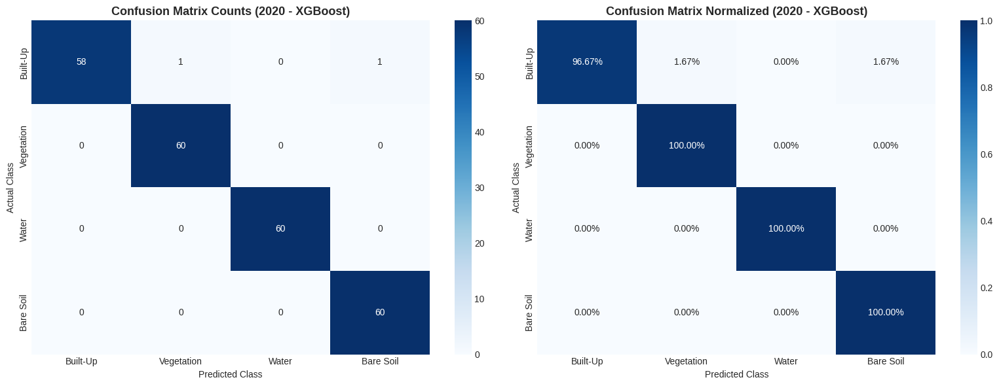

In [ ]:
# --- Detailed Test Set Classification Report ---
target_names = [CLASS_NAMES[i+1] for i in range(len(np.unique(y_test)))]
y_pred = model.predict(X_test)

print(f"==================================================")
print(f" Detailed Test Set Classification Report (2020 - XGBoost)")
print(f"==================================================")
print(classification_report(y_test, y_pred, target_names=target_names))

# --- Confusion Matrix Calculation & Plotting ---
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Counts heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title(f'Confusion Matrix Counts (2020 - XGBoost)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Class')
axes[0].set_xlabel('Predicted Class')

# Normalized heatmap
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title(f'Confusion Matrix Normalized (2020 - XGBoost)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Class')
axes[1].set_xlabel('Predicted Class')

plt.tight_layout()
plt.savefig(f'confusion_matrix_2020.png', dpi=150, bbox_inches='tight')
plt.show()


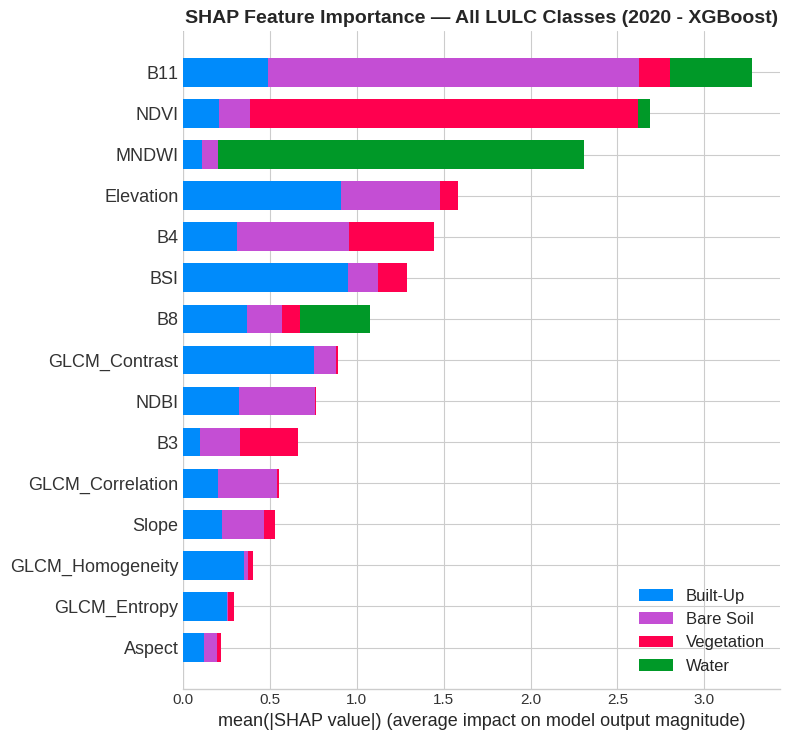


--- SHAP Beeswarm: Built-Up (2020) ---


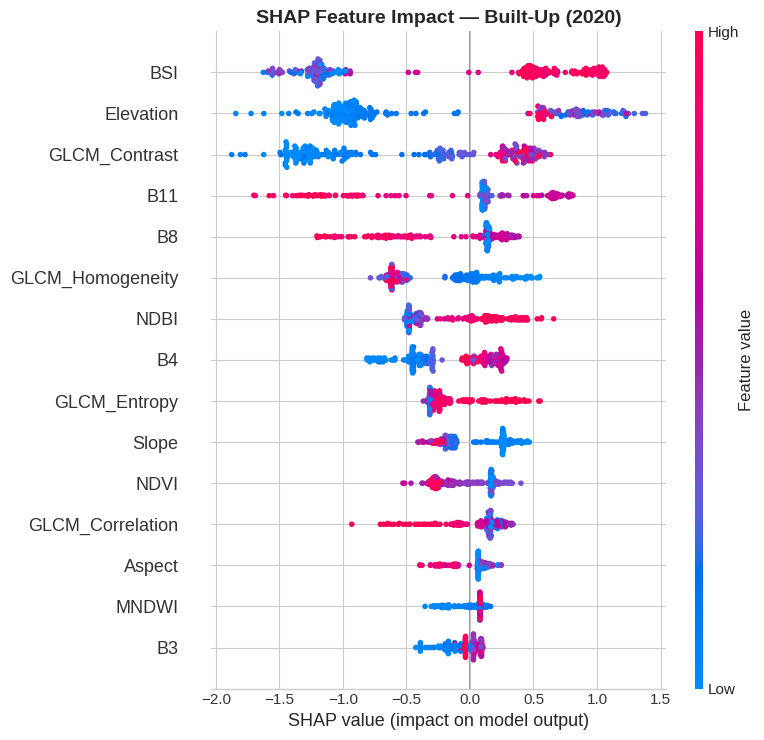


--- SHAP Beeswarm: Vegetation (2020) ---


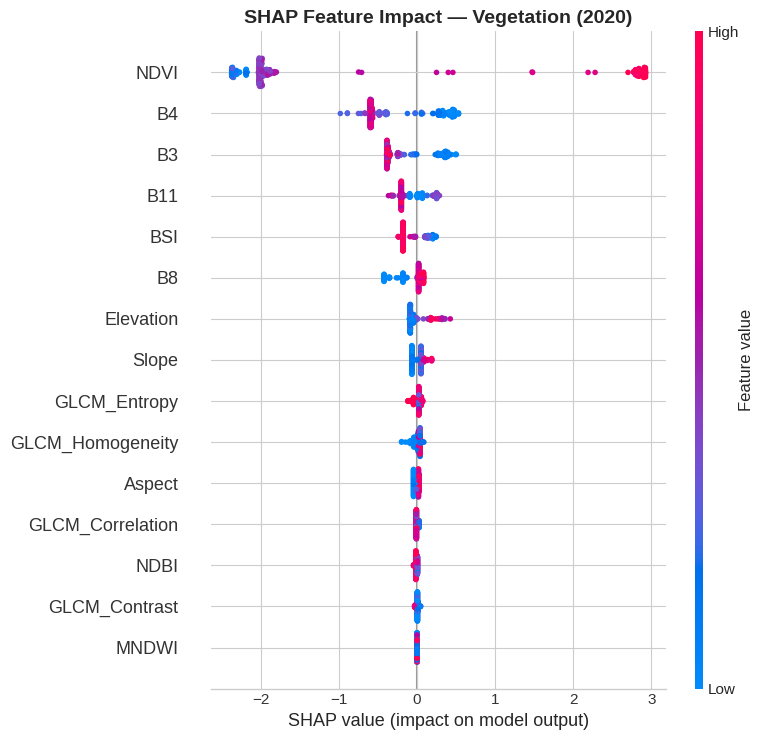


--- SHAP Beeswarm: Water (2020) ---


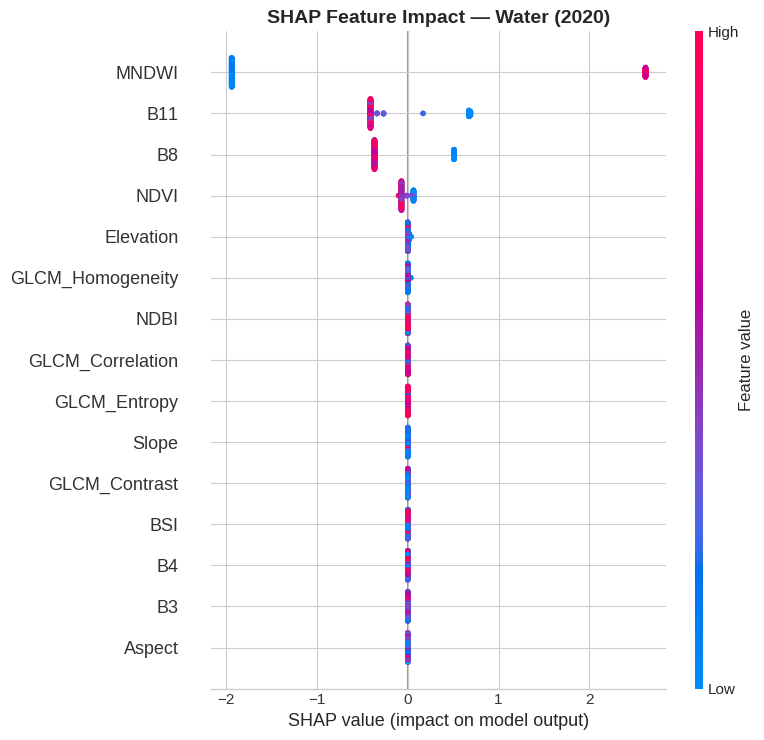


--- SHAP Beeswarm: Bare Soil (2020) ---


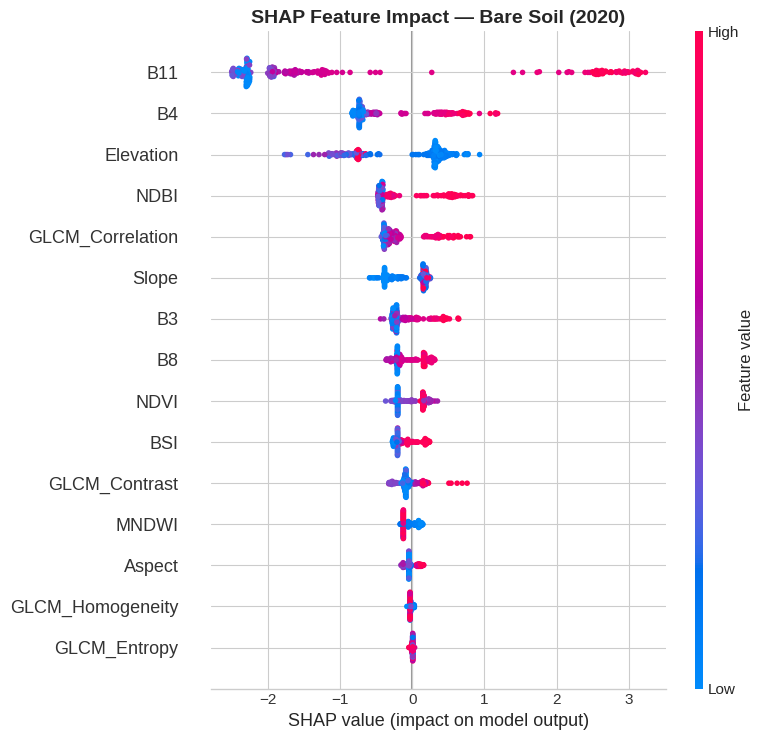

In [ ]:
# ============================================================================
# SHAP GLOBAL EXPLANABILITY
# ============================================================================
# Initialize DataFrame from test set for plotting
X_test_df = pd.DataFrame(X_test, columns=FEATURE_COLS)

# Compute SHAP values using TreeExplainer (optimized for XGBoost)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# --- SHAP Bar Plot — Mean |SHAP| across all classes ---
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_df, plot_type='bar', class_names=target_names, show=False)
plt.title(f'SHAP Feature Importance — All LULC Classes ({TARGET_YEAR} - {best_algorithm})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_summary_bar_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

# --- SHAP Beeswarm Plot — Per Class ---
for cls_idx in range(len(target_names)):
    cls_name = CLASS_NAMES[cls_idx + 1]
    print(f"\n--- SHAP Beeswarm: {cls_name} ({TARGET_YEAR}) ---")
    fig = plt.figure(figsize=(12, 8))

    # Handle SHAP output dimensions for tree models
    if isinstance(shap_values, list):
        sv = shap_values[cls_idx]
    elif shap_values.ndim == 3:
        sv = shap_values[:, :, cls_idx]
    else:
        sv = shap_values

    shap.summary_plot(sv, X_test_df, show=False)
    plt.title(f'SHAP Feature Impact — {cls_name} ({TARGET_YEAR})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_beeswarm_{cls_name.lower().replace(" ", "_")}_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
    plt.show()


Features in order of importance for 2020: ['B11', 'NDVI', 'MNDWI', 'Elevation', 'B4', 'BSI', 'B8', 'GLCM_Contrast', 'NDBI', 'B3', 'GLCM_Correlation', 'Slope', 'GLCM_Homogeneity', 'GLCM_Entropy', 'Aspect']


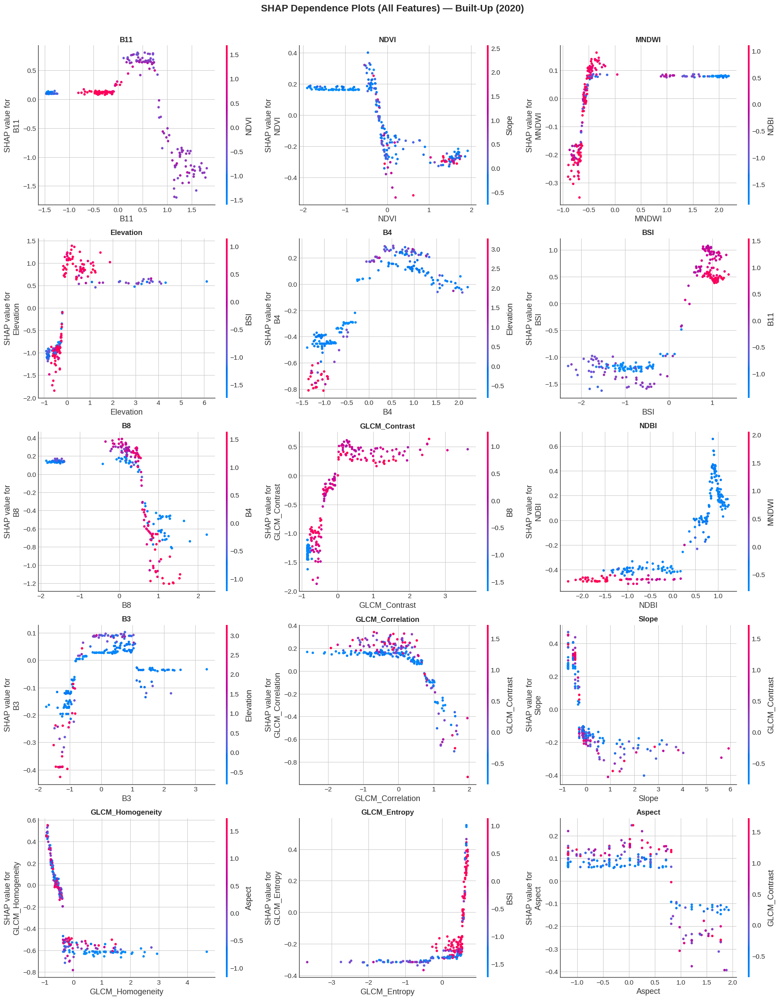

In [ ]:
# ============================================================================
# SHAP DEPENDENCE PLOTS
# ============================================================================
# Determine feature importance rankings from absolute SHAP values
if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

top_features_idx = np.argsort(mean_abs_shap)[::-1]
top_feature_names = [FEATURE_COLS[i] for i in top_features_idx]
print(f"Features in order of importance for {TARGET_YEAR}: {top_feature_names}")

num_features = len(FEATURE_COLS)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

# Plot dependency for the first class (Built-Up)
cls_dep = 0
if isinstance(shap_values, list):
    sv_dep = shap_values[cls_dep]
elif shap_values.ndim == 3:
    sv_dep = shap_values[:, :, cls_dep]
else:
    sv_dep = shap_values

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 4.5 * num_rows))
axes_flat = axes.flat

for i, feat_idx in enumerate(top_features_idx):
    ax = axes_flat[i]
    shap.dependence_plot(
        feat_idx, sv_dep, X_test_df,
        interaction_index='auto', ax=ax, show=False
    )
    ax.set_title(f'{FEATURE_COLS[feat_idx]}', fontsize=12, fontweight='bold')

for i in range(num_features, len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.suptitle(f'SHAP Dependence Plots (All Features) — {CLASS_NAMES[cls_dep+1]} ({TARGET_YEAR})', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'shap_dependence_all_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()



--- Generating SHAP Waterfall Plots (2020) ---


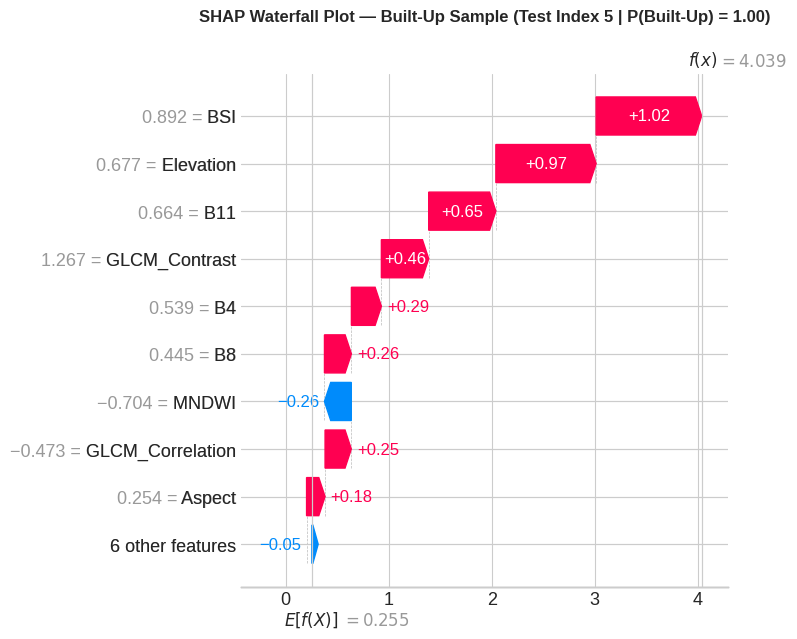

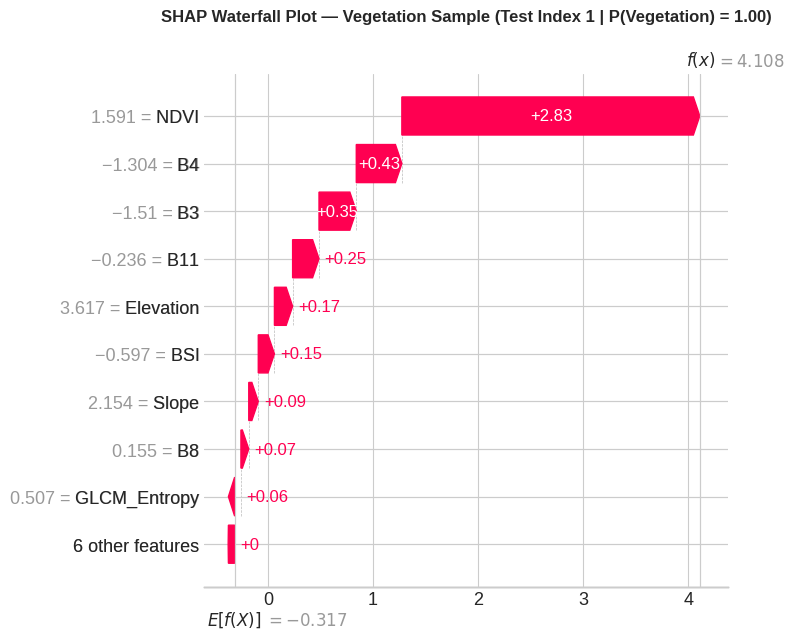

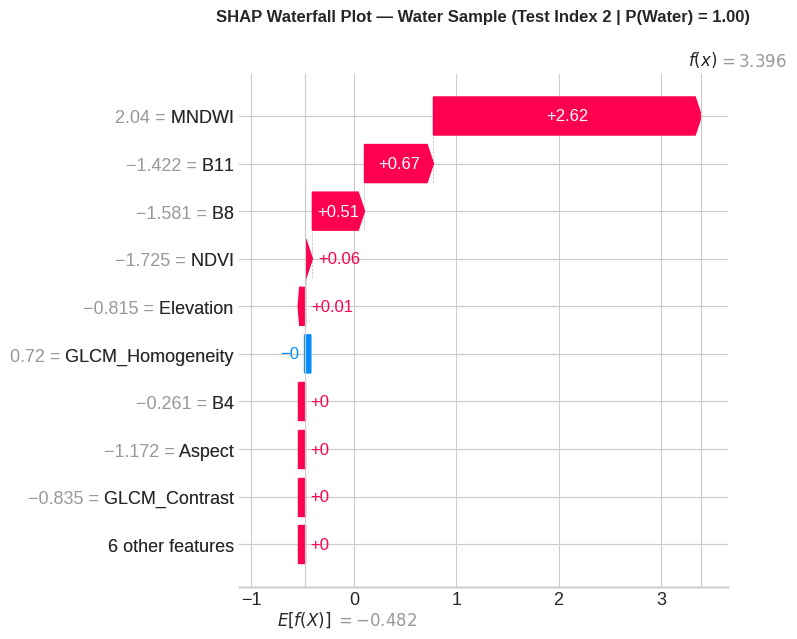

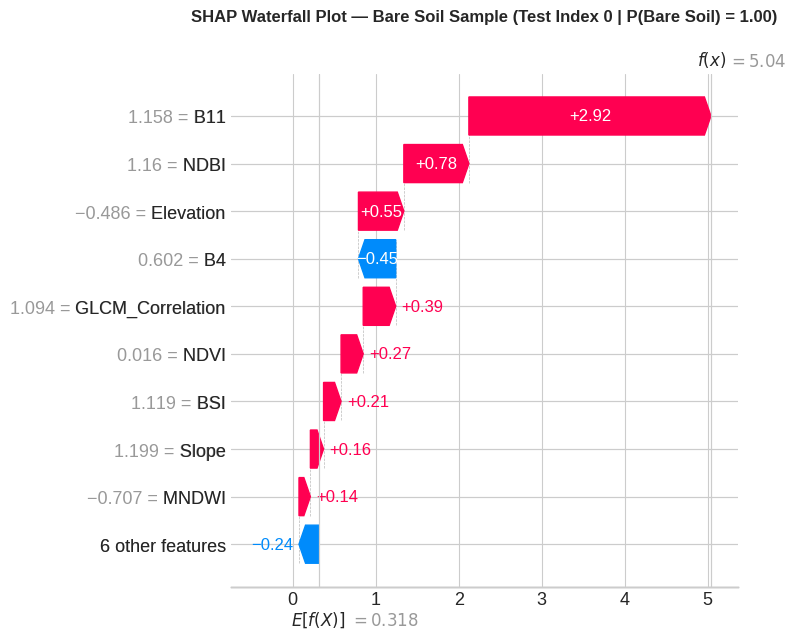

In [ ]:
# ============================================================================
# SHAP WATERFALL PLOTS
# ============================================================================
print(f"\n--- Generating SHAP Waterfall Plots ({TARGET_YEAR}) ---")
y_pred_test = model.predict(X_test)
num_classes = len(target_names)

for cls_idx in range(num_classes):
    cls_name = CLASS_NAMES[cls_idx + 1]
    cls_mask = y_test == cls_idx
    correct_mask = cls_mask & (y_pred_test == cls_idx)

    if np.sum(correct_mask) > 0:
        # Pick the first correctly predicted sample for this class
        sample_idx = np.where(correct_mask)[0][0]

        # Format prediction probability string
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test[sample_idx:sample_idx+1])[0]
            prob_str = f"P({cls_name}) = {probs[cls_idx]:.2f}"
        else:
            prob_str = "Correct Prediction"

        # Compute SHAP explanation object for waterfall plot
        if isinstance(shap_values, list):
            sv_sample = shap_values[cls_idx][sample_idx]
            base_val = explainer.expected_value[cls_idx]
        elif shap_values.ndim == 3:
            sv_sample = shap_values[sample_idx, :, cls_idx]
            base_val = explainer.expected_value[cls_idx]
        else:
            sv_sample = shap_values[sample_idx]
            base_val = explainer.expected_value

        exp = shap.Explanation(
            values=sv_sample,
            base_values=base_val,
            data=X_test[sample_idx],
            feature_names=FEATURE_COLS
        )

        fig = plt.figure(figsize=(10, 6))
        shap.plots.waterfall(exp, show=False)
        plt.title(f'SHAP Waterfall Plot — {cls_name} Sample (Test Index {sample_idx} | {prob_str})', fontsize=12, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'shap_waterfall_{cls_name.lower().replace(" ", "_")}_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
         print(f"No correctly predicted samples found for class {cls_name}.")


In [ ]:
# ============================================================================
# SAVE PIPELINE ARTIFACTS
# ============================================================================
import joblib

# 1. Save the active year's XGBoost model and its corresponding scaler
model_filename = os.path.join(DATA_DIR, f'best_model_{TARGET_YEAR}.joblib')
scaler_filename = os.path.join(DATA_DIR, f'scaler_{TARGET_YEAR}.joblib')

joblib.dump(model, model_filename)
joblib.dump(scaler, scaler_filename)

print(f"✓ Model successfully saved: {os.path.basename(model_filename)}")
print(f"✓ Scaler successfully saved: {os.path.basename(scaler_filename)}")

# 2. Compute and export global SHAP feature importances to CSV
if isinstance(shap_values, list):
    global_importances = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    global_importances = np.abs(shap_values).mean(axis=(0, 2))
else:
    global_importances = np.abs(shap_values).mean(axis=0)

importance_summary_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Mean_Absolute_SHAP': global_importances
}).sort_values('Mean_Absolute_SHAP', ascending=False)

csv_filename = os.path.join(DATA_DIR, f'shap_feature_importance_{TARGET_YEAR}.csv')
importance_summary_df.to_csv(csv_filename, index=False)
print(f"✓ SHAP global feature importances exported to: {os.path.basename(csv_filename)}")


✓ Model successfully saved: best_model_2020.joblib
✓ Scaler successfully saved: scaler_2020.joblib
✓ SHAP global feature importances exported to: shap_feature_importance_2020.csv


In [ ]:
# 2022
# Set the target year to 2022
TARGET_YEAR = 2022

# We use XGBoost because it was established as the best overall performing model
best_algorithm = 'XGBoost'
model = MODELS[TARGET_YEAR][best_algorithm]
scaler = SPLIT_DATA[TARGET_YEAR]['scaler']

# Extract the year-specific split datasets and features for downstream cells
X_train = SPLIT_DATA[TARGET_YEAR]['X_train']
X_val = SPLIT_DATA[TARGET_YEAR]['X_val']
X_test = SPLIT_DATA[TARGET_YEAR]['X_test']
y_train = SPLIT_DATA[TARGET_YEAR]['y_train']
y_val = SPLIT_DATA[TARGET_YEAR]['y_val']
y_test = SPLIT_DATA[TARGET_YEAR]['y_test']
FEATURE_COLS = FEATURE_COLS_MAP[TARGET_YEAR]

print(f"==================================================")
print(f" Activated XGBoost Model for Year {TARGET_YEAR}")
print(f"==================================================")


 Activated XGBoost Model for Year 2022


 Detailed Test Set Classification Report (2022 - XGBoost)
              precision    recall  f1-score   support

    Built-Up       0.93      0.90      0.92        60
  Vegetation       1.00      0.98      0.99        60
       Water       1.00      1.00      1.00        60
   Bare Soil       0.90      0.95      0.93        60

    accuracy                           0.96       240
   macro avg       0.96      0.96      0.96       240
weighted avg       0.96      0.96      0.96       240



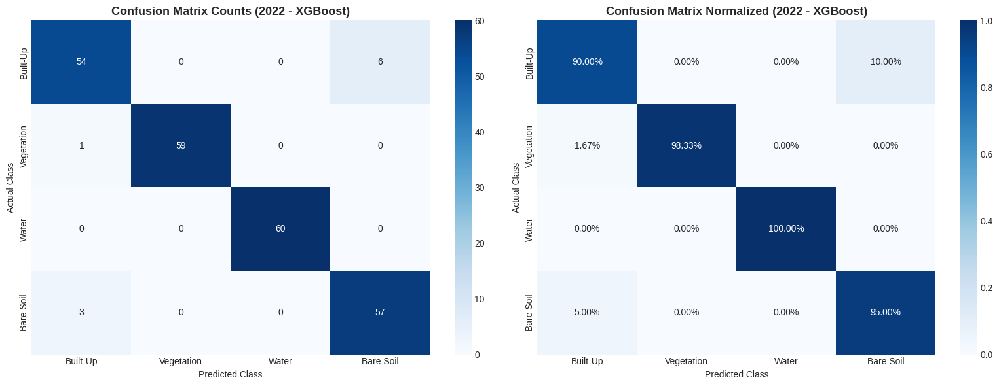

In [ ]:
# --- Detailed Test Set Classification Report ---
target_names = [CLASS_NAMES[i+1] for i in range(len(np.unique(y_test)))]
y_pred = model.predict(X_test)

print(f"==================================================")
print(f" Detailed Test Set Classification Report ({TARGET_YEAR} - XGBoost)")
print(f"==================================================")
print(classification_report(y_test, y_pred, target_names=target_names))

# --- Confusion Matrix Calculation & Plotting ---
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Counts heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title(f'Confusion Matrix Counts ({TARGET_YEAR} - XGBoost)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Class')
axes[0].set_xlabel('Predicted Class')

# Normalized heatmap
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title(f'Confusion Matrix Normalized ({TARGET_YEAR} - XGBoost)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Class')
axes[1].set_xlabel('Predicted Class')

plt.tight_layout()
plt.savefig(f'confusion_matrix_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()


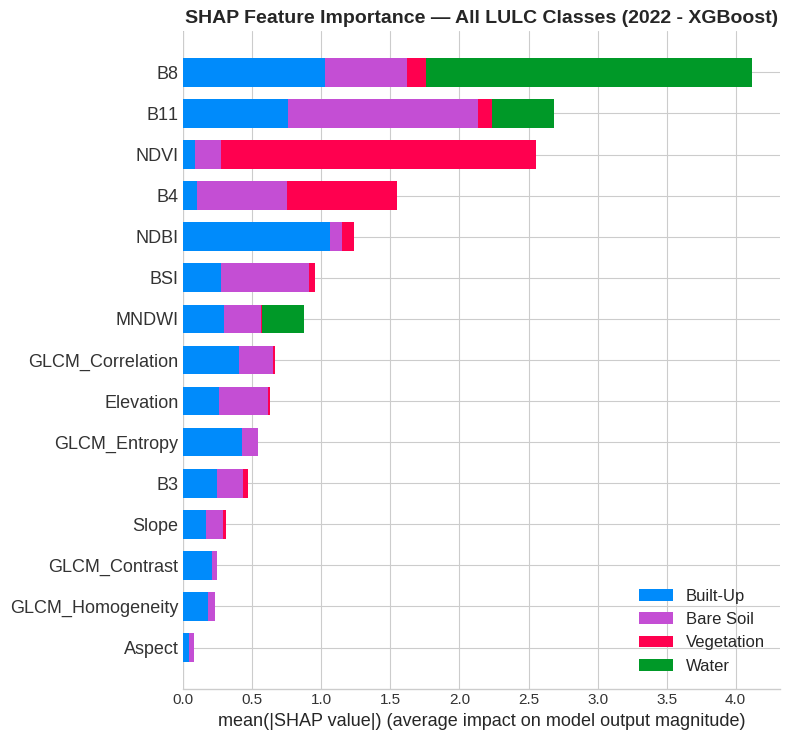


--- SHAP Beeswarm: Built-Up (2022) ---


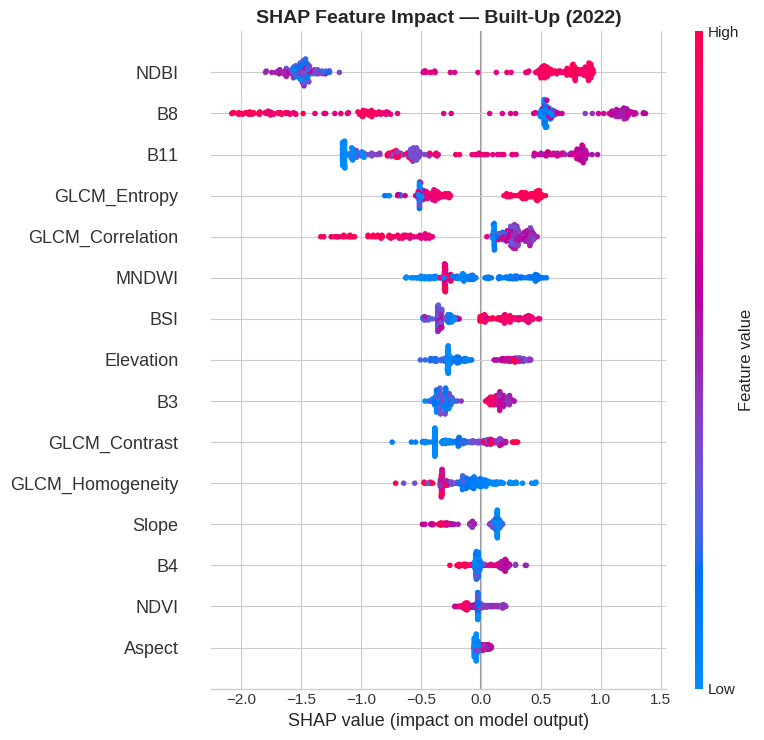


--- SHAP Beeswarm: Vegetation (2022) ---


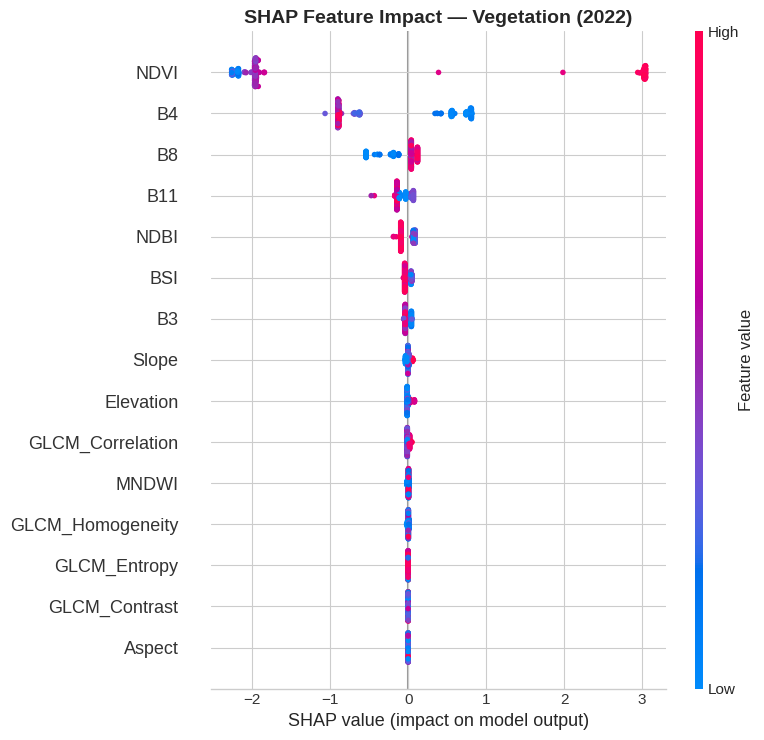


--- SHAP Beeswarm: Water (2022) ---


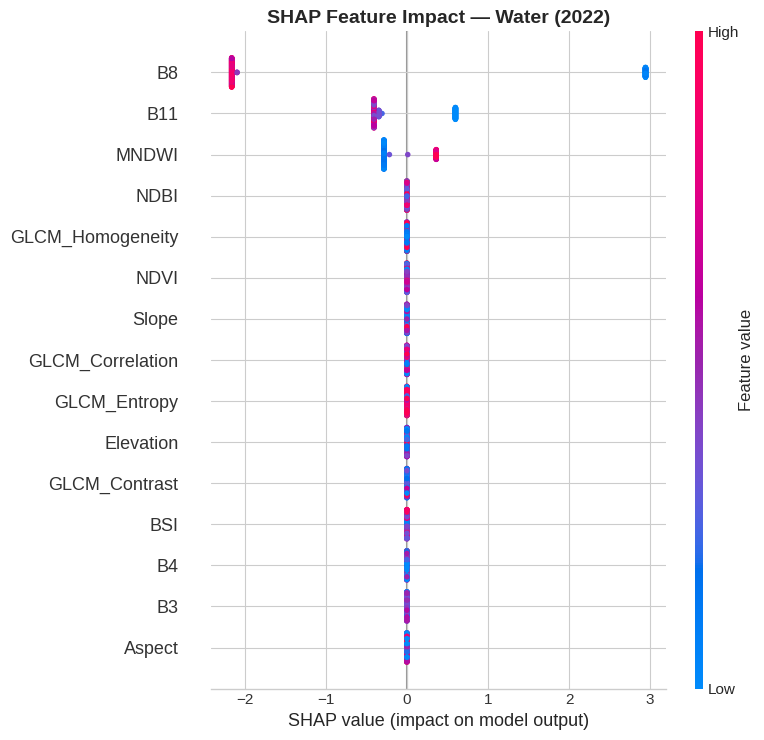


--- SHAP Beeswarm: Bare Soil (2022) ---


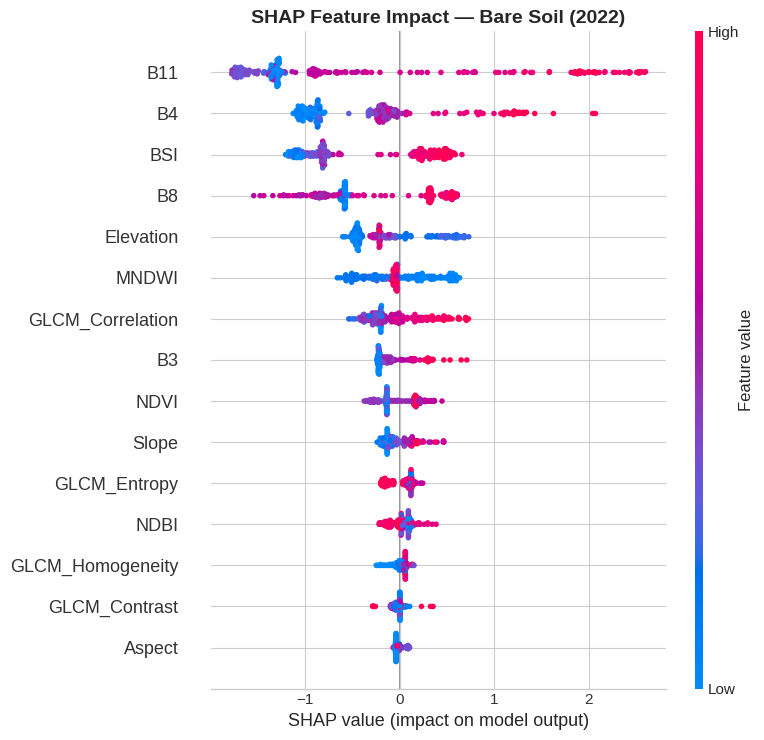

In [ ]:
# ============================================================================
# SHAP GLOBAL EXPLANABILITY
# ============================================================================
# Initialize DataFrame from test set for plotting
X_test_df = pd.DataFrame(X_test, columns=FEATURE_COLS)

# Compute SHAP values using TreeExplainer (optimized for XGBoost)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# --- SHAP Bar Plot — Mean |SHAP| across all classes ---
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_df, plot_type='bar', class_names=target_names, show=False)
plt.title(f'SHAP Feature Importance — All LULC Classes ({TARGET_YEAR} - XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_summary_bar_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

# --- SHAP Beeswarm Plot — Per Class ---
for cls_idx in range(len(target_names)):
    cls_name = CLASS_NAMES[cls_idx + 1]
    print(f"\n--- SHAP Beeswarm: {cls_name} ({TARGET_YEAR}) ---")
    fig = plt.figure(figsize=(12, 8))

    # Handle SHAP output dimensions for tree models
    if isinstance(shap_values, list):
        sv = shap_values[cls_idx]
    elif shap_values.ndim == 3:
        sv = shap_values[:, :, cls_idx]
    else:
        sv = shap_values

    shap.summary_plot(sv, X_test_df, show=False)
    plt.title(f'SHAP Feature Impact — {cls_name} ({TARGET_YEAR})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_beeswarm_{cls_name.lower().replace(" ", "_")}_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
    plt.show()


Features in order of importance for 2022: ['B8', 'B11', 'NDVI', 'B4', 'NDBI', 'BSI', 'MNDWI', 'GLCM_Correlation', 'Elevation', 'GLCM_Entropy', 'B3', 'Slope', 'GLCM_Contrast', 'GLCM_Homogeneity', 'Aspect']


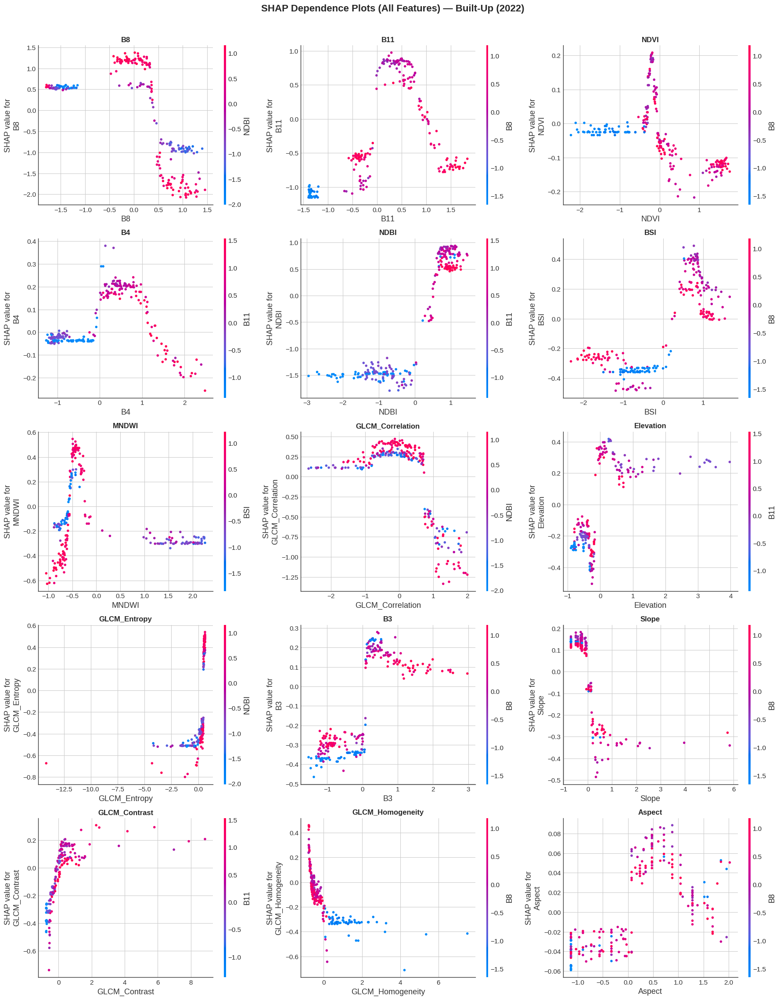

In [ ]:
# ============================================================================
# SHAP DEPENDENCE PLOTS
# ============================================================================
# Determine feature importance rankings from absolute SHAP values
if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

top_features_idx = np.argsort(mean_abs_shap)[::-1]
top_feature_names = [FEATURE_COLS[i] for i in top_features_idx]
print(f"Features in order of importance for {TARGET_YEAR}: {top_feature_names}")

num_features = len(FEATURE_COLS)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

# Plot dependency for the first class (Built-Up)
cls_dep = 0
if isinstance(shap_values, list):
    sv_dep = shap_values[cls_dep]
elif shap_values.ndim == 3:
    sv_dep = shap_values[:, :, cls_dep]
else:
    sv_dep = shap_values

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 4.5 * num_rows))
axes_flat = axes.flat

for i, feat_idx in enumerate(top_features_idx):
    ax = axes_flat[i]
    shap.dependence_plot(
        feat_idx, sv_dep, X_test_df,
        interaction_index='auto', ax=ax, show=False
    )
    ax.set_title(f'{FEATURE_COLS[feat_idx]}', fontsize=12, fontweight='bold')

for i in range(num_features, len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.suptitle(f'SHAP Dependence Plots (All Features) — {CLASS_NAMES[cls_dep+1]} ({TARGET_YEAR})', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'shap_dependence_all_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()



--- Generating SHAP Waterfall Plots (2022) ---


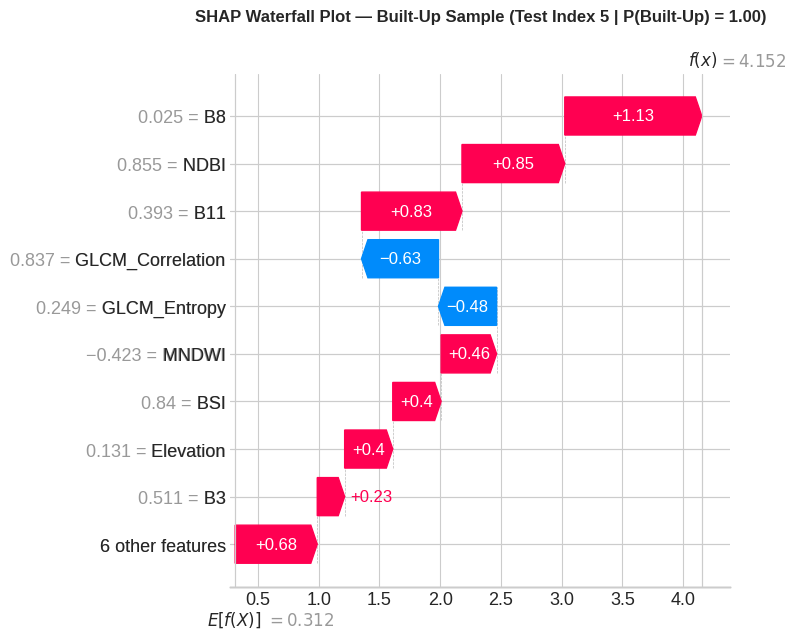

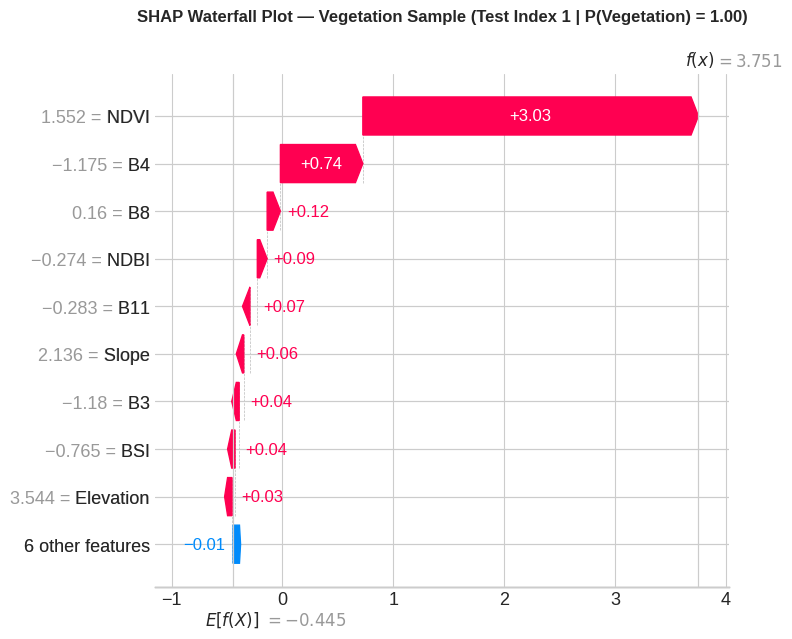

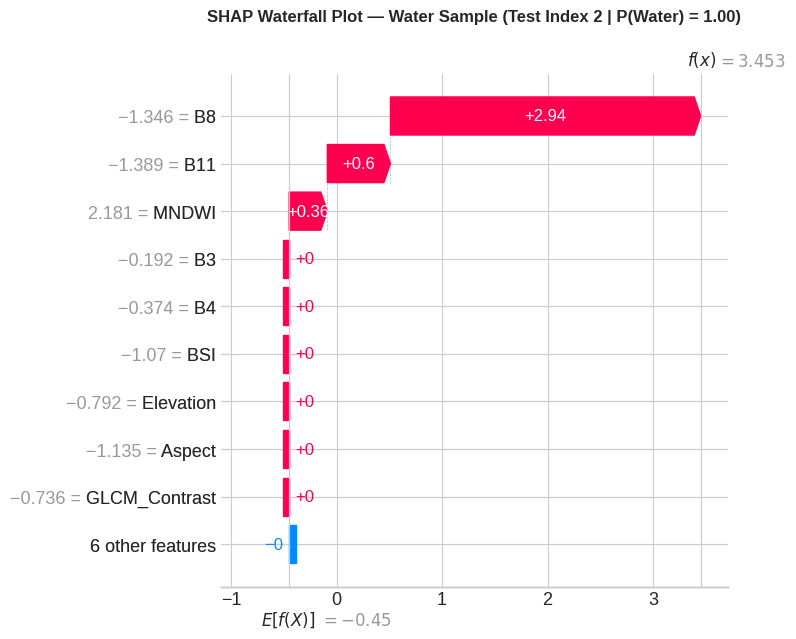

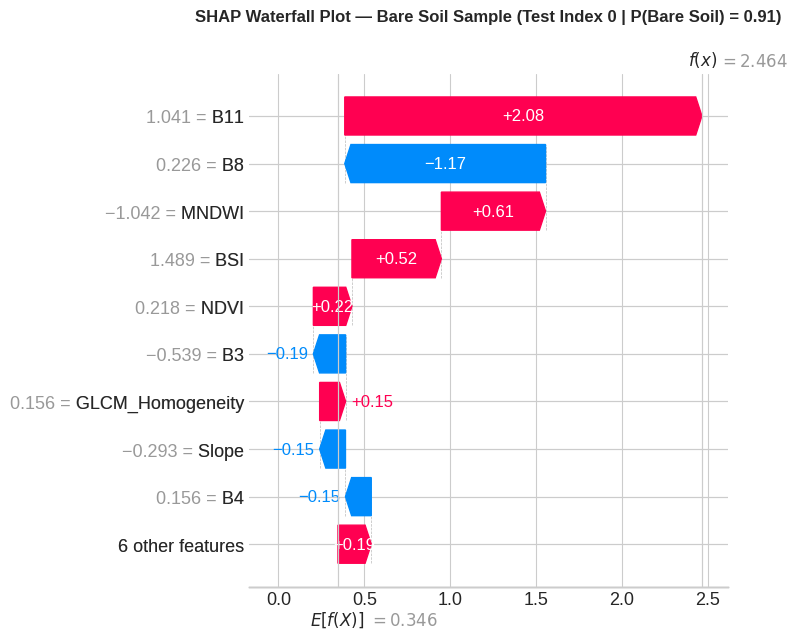

In [ ]:
# ============================================================================
# SHAP WATERFALL PLOTS
# ============================================================================
print(f"\n--- Generating SHAP Waterfall Plots ({TARGET_YEAR}) ---")
y_pred_test = model.predict(X_test)
num_classes = len(target_names)

for cls_idx in range(num_classes):
    cls_name = CLASS_NAMES[cls_idx + 1]
    cls_mask = y_test == cls_idx
    correct_mask = cls_mask & (y_pred_test == cls_idx)

    if np.sum(correct_mask) > 0:
        # Pick the first correctly predicted sample for this class
        sample_idx = np.where(correct_mask)[0][0]

        # Format prediction probability string
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test[sample_idx:sample_idx+1])[0]
            prob_str = f"P({cls_name}) = {probs[cls_idx]:.2f}"
        else:
            prob_str = "Correct Prediction"

        # Compute SHAP explanation object for waterfall plot
        if isinstance(shap_values, list):
            sv_sample = shap_values[cls_idx][sample_idx]
            base_val = explainer.expected_value[cls_idx]
        elif shap_values.ndim == 3:
            sv_sample = shap_values[sample_idx, :, cls_idx]
            base_val = explainer.expected_value[cls_idx]
        else:
            sv_sample = shap_values[sample_idx]
            base_val = explainer.expected_value

        exp = shap.Explanation(
            values=sv_sample,
            base_values=base_val,
            data=X_test[sample_idx],
            feature_names=FEATURE_COLS
        )

        fig = plt.figure(figsize=(10, 6))
        shap.plots.waterfall(exp, show=False)
        plt.title(f'SHAP Waterfall Plot — {cls_name} Sample (Test Index {sample_idx} | {prob_str})', fontsize=12, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'shap_waterfall_{cls_name.lower().replace(" ", "_")}_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
         print(f"No correctly predicted samples found for class {cls_name}.")


In [ ]:
# ============================================================================
# SAVE PIPELINE ARTIFACTS
# ============================================================================
import joblib

# 1. Save the 2022 XGBoost model and its corresponding scaler
model_filename = os.path.join(DATA_DIR, f'best_model_{TARGET_YEAR}.joblib')
scaler_filename = os.path.join(DATA_DIR, f'scaler_{TARGET_YEAR}.joblib')

joblib.dump(model, model_filename)
joblib.dump(scaler, scaler_filename)

print(f"✓ Model successfully saved: {os.path.basename(model_filename)}")
print(f"✓ Scaler successfully saved: {os.path.basename(scaler_filename)}")

# 2. Compute and export global SHAP feature importances to CSV
if isinstance(shap_values, list):
    global_importances = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    global_importances = np.abs(shap_values).mean(axis=(0, 2))
else:
    global_importances = np.abs(shap_values).mean(axis=0)

importance_summary_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Mean_Absolute_SHAP': global_importances
}).sort_values('Mean_Absolute_SHAP', ascending=False)

csv_filename = os.path.join(DATA_DIR, f'shap_feature_importance_{TARGET_YEAR}.csv')
importance_summary_df.to_csv(csv_filename, index=False)
print(f"✓ SHAP global feature importances exported to: {os.path.basename(csv_filename)}")


✓ Model successfully saved: best_model_2022.joblib
✓ Scaler successfully saved: scaler_2022.joblib
✓ SHAP global feature importances exported to: shap_feature_importance_2022.csv


In [ ]:
# Set the target year to 2024
TARGET_YEAR = 2024

# We use XGBoost because it was established as the best overall performing model
best_algorithm = 'XGBoost'
model = MODELS[TARGET_YEAR][best_algorithm]
scaler = SPLIT_DATA[TARGET_YEAR]['scaler']

# Extract the year-specific split datasets and features for downstream cells
X_train = SPLIT_DATA[TARGET_YEAR]['X_train']
X_val = SPLIT_DATA[TARGET_YEAR]['X_val']
X_test = SPLIT_DATA[TARGET_YEAR]['X_test']
y_train = SPLIT_DATA[TARGET_YEAR]['y_train']
y_val = SPLIT_DATA[TARGET_YEAR]['y_val']
y_test = SPLIT_DATA[TARGET_YEAR]['y_test']
FEATURE_COLS = FEATURE_COLS_MAP[TARGET_YEAR]

print(f"==================================================")
print(f" Activated XGBoost Model for Year {TARGET_YEAR}")
print(f"==================================================")


 Activated XGBoost Model for Year 2024


 Detailed Test Set Classification Report (2024 - XGBoost)
              precision    recall  f1-score   support

    Built-Up       0.95      0.98      0.97        60
  Vegetation       1.00      1.00      1.00        60
       Water       1.00      1.00      1.00        60
   Bare Soil       0.98      0.95      0.97        60

    accuracy                           0.98       240
   macro avg       0.98      0.98      0.98       240
weighted avg       0.98      0.98      0.98       240



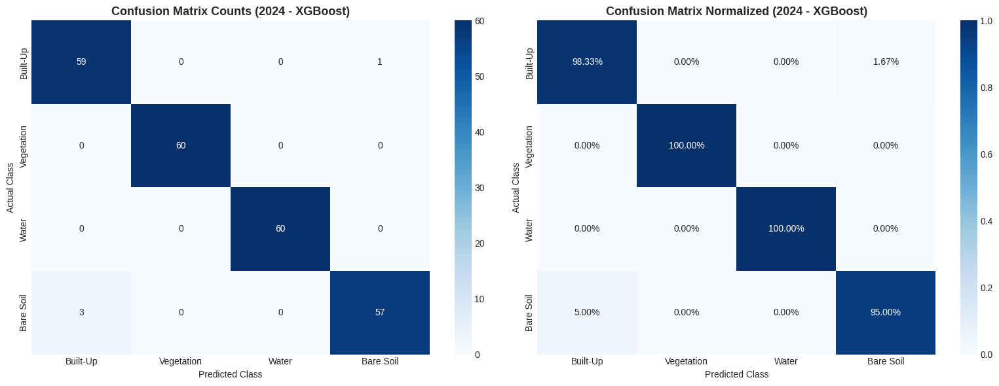

In [ ]:
# --- Detailed Test Set Classification Report ---
target_names = [CLASS_NAMES[i+1] for i in range(len(np.unique(y_test)))]
y_pred = model.predict(X_test)

print(f"==================================================")
print(f" Detailed Test Set Classification Report ({TARGET_YEAR} - XGBoost)")
print(f"==================================================")
print(classification_report(y_test, y_pred, target_names=target_names))

# --- Confusion Matrix Calculation & Plotting ---
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Counts heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title(f'Confusion Matrix Counts ({TARGET_YEAR} - XGBoost)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Class')
axes[0].set_xlabel('Predicted Class')

# Normalized heatmap
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title(f'Confusion Matrix Normalized ({TARGET_YEAR} - XGBoost)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Class')
axes[1].set_xlabel('Predicted Class')

plt.tight_layout()
plt.savefig(f'confusion_matrix_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()


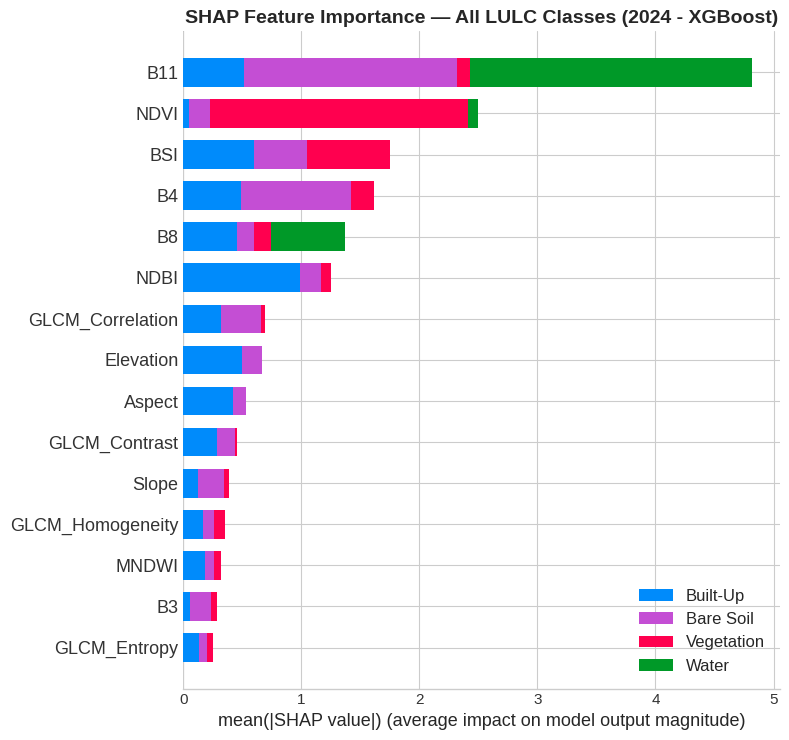


--- SHAP Beeswarm: Built-Up (2024) ---


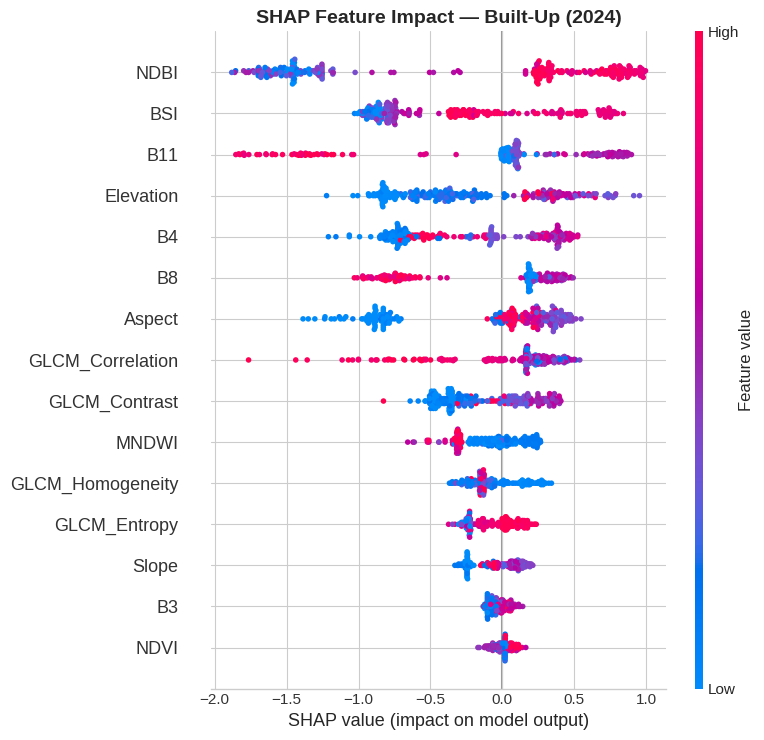


--- SHAP Beeswarm: Vegetation (2024) ---


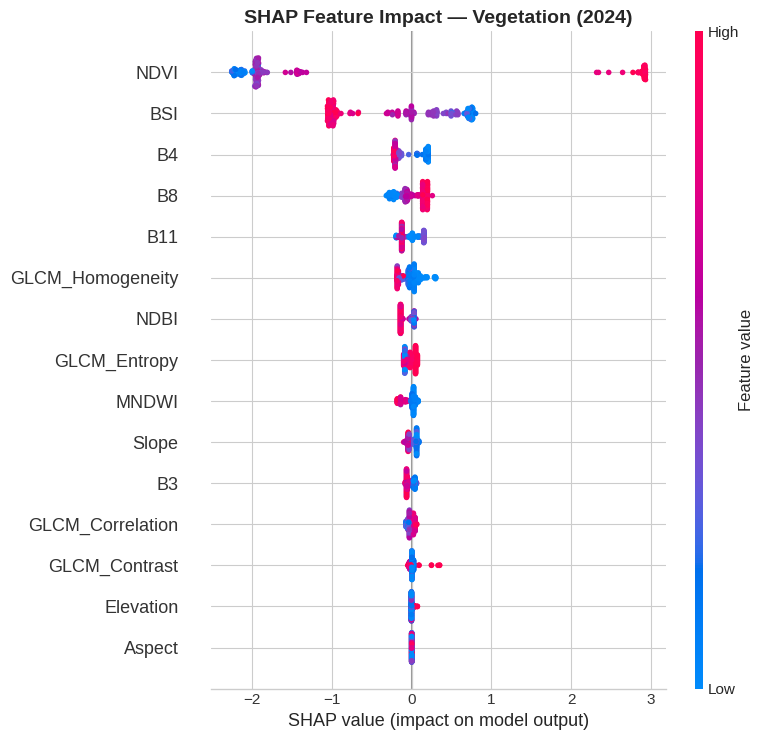


--- SHAP Beeswarm: Water (2024) ---


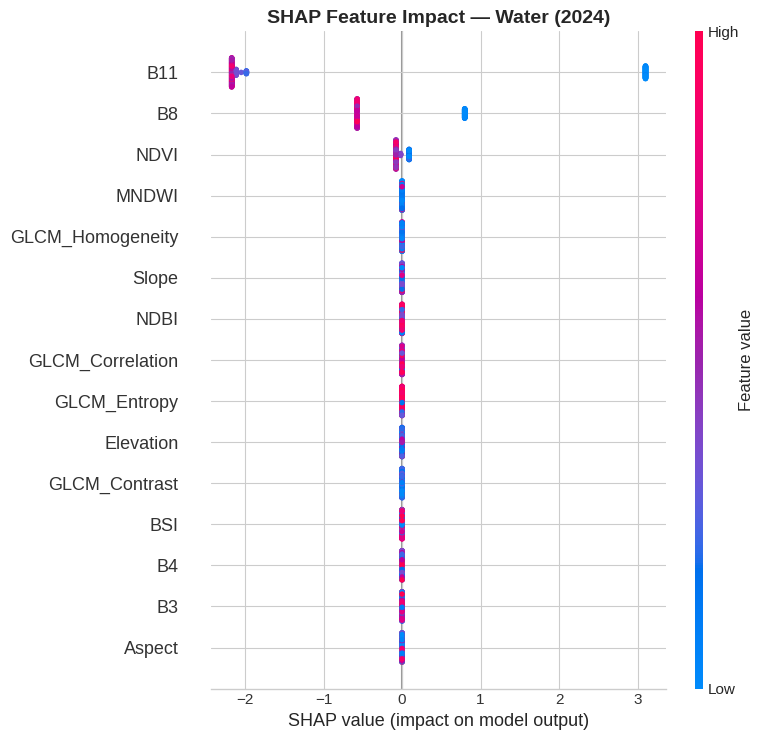


--- SHAP Beeswarm: Bare Soil (2024) ---


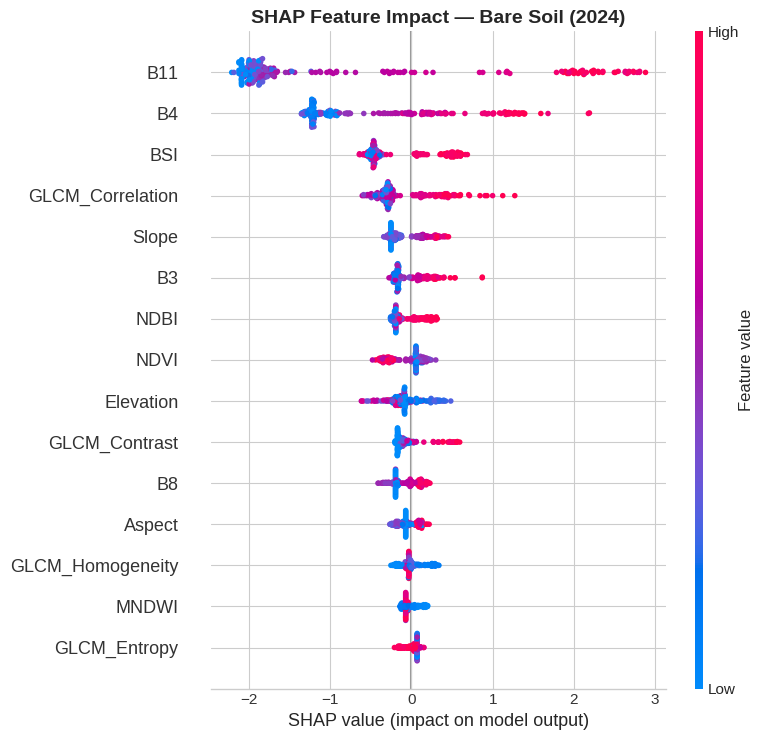

In [ ]:
# ============================================================================
# SHAP GLOBAL EXPLANABILITY
# ============================================================================
# Initialize DataFrame from test set for plotting
X_test_df = pd.DataFrame(X_test, columns=FEATURE_COLS)

# Compute SHAP values using TreeExplainer (optimized for XGBoost)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# --- SHAP Bar Plot — Mean |SHAP| across all classes ---
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_df, plot_type='bar', class_names=target_names, show=False)
plt.title(f'SHAP Feature Importance — All LULC Classes ({TARGET_YEAR} - XGBoost)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_summary_bar_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()

# --- SHAP Beeswarm Plot — Per Class ---
for cls_idx in range(len(target_names)):
    cls_name = CLASS_NAMES[cls_idx + 1]
    print(f"\n--- SHAP Beeswarm: {cls_name} ({TARGET_YEAR}) ---")
    fig = plt.figure(figsize=(12, 8))

    # Handle SHAP output dimensions for tree models
    if isinstance(shap_values, list):
        sv = shap_values[cls_idx]
    elif shap_values.ndim == 3:
        sv = shap_values[:, :, cls_idx]
    else:
        sv = shap_values

    shap.summary_plot(sv, X_test_df, show=False)
    plt.title(f'SHAP Feature Impact — {cls_name} ({TARGET_YEAR})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_beeswarm_{cls_name.lower().replace(" ", "_")}_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
    plt.show()



Features in order of importance for 2024: ['B11', 'NDVI', 'BSI', 'B4', 'B8', 'NDBI', 'GLCM_Correlation', 'Elevation', 'Aspect', 'GLCM_Contrast', 'Slope', 'GLCM_Homogeneity', 'MNDWI', 'B3', 'GLCM_Entropy']


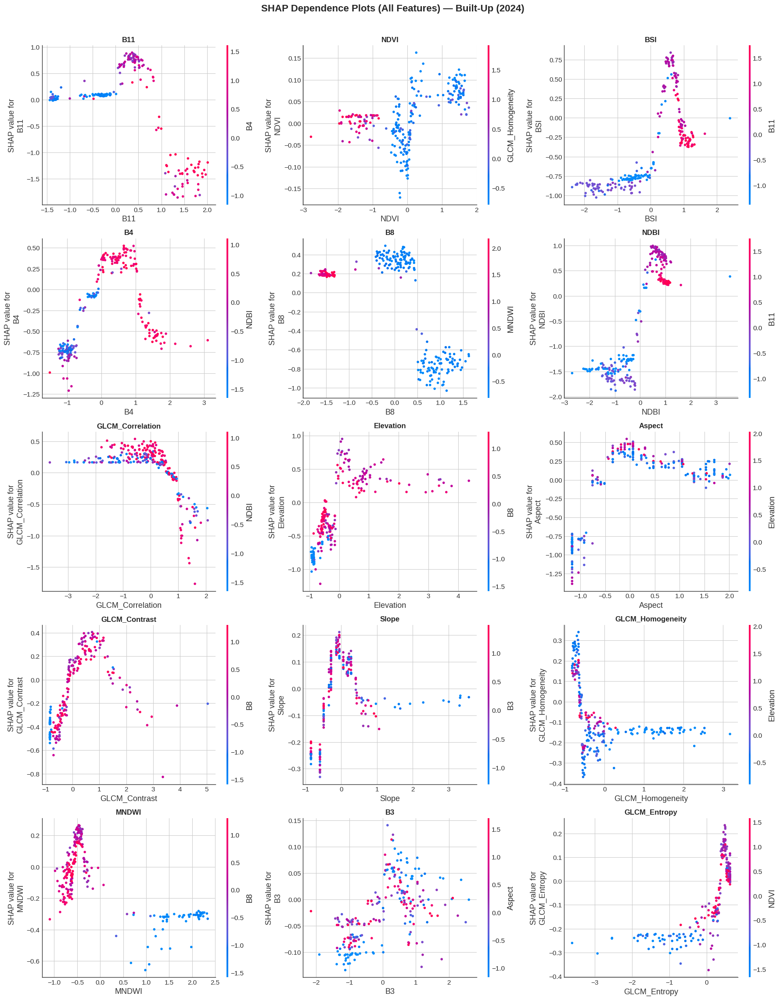

In [ ]:
# ============================================================================
# SHAP DEPENDENCE PLOTS
# ============================================================================
# Determine feature importance rankings from absolute SHAP values
if isinstance(shap_values, list):
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

top_features_idx = np.argsort(mean_abs_shap)[::-1]
top_feature_names = [FEATURE_COLS[i] for i in top_features_idx]
print(f"Features in order of importance for {TARGET_YEAR}: {top_feature_names}")

num_features = len(FEATURE_COLS)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

# Plot dependency for the first class (Built-Up)
cls_dep = 0
if isinstance(shap_values, list):
    sv_dep = shap_values[cls_dep]
elif shap_values.ndim == 3:
    sv_dep = shap_values[:, :, cls_dep]
else:
    sv_dep = shap_values

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 4.5 * num_rows))
axes_flat = axes.flat

for i, feat_idx in enumerate(top_features_idx):
    ax = axes_flat[i]
    shap.dependence_plot(
        feat_idx, sv_dep, X_test_df,
        interaction_index='auto', ax=ax, show=False
    )
    ax.set_title(f'{FEATURE_COLS[feat_idx]}', fontsize=12, fontweight='bold')

for i in range(num_features, len(axes_flat)):
    fig.delaxes(axes_flat[i])

plt.suptitle(f'SHAP Dependence Plots (All Features) — {CLASS_NAMES[cls_dep+1]} ({TARGET_YEAR})', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'shap_dependence_all_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()



--- Generating SHAP Waterfall Plots (2024) ---


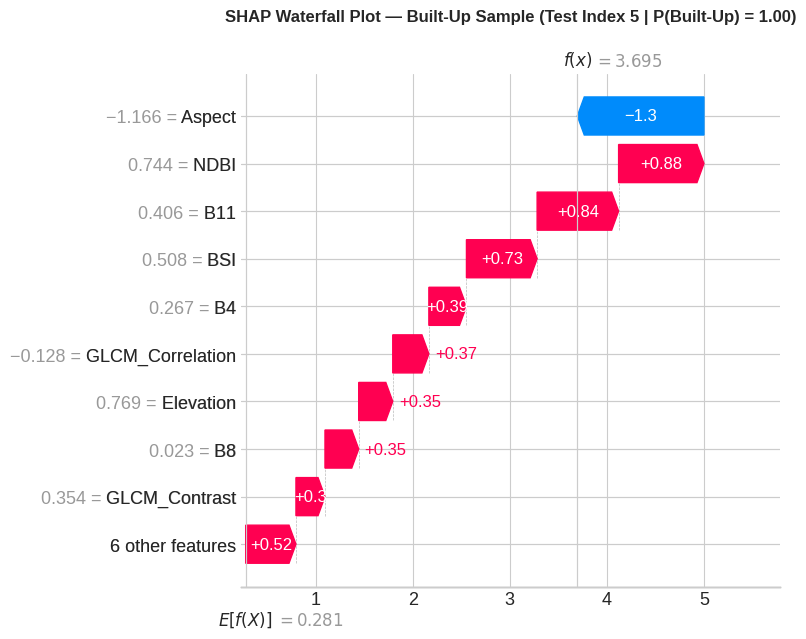

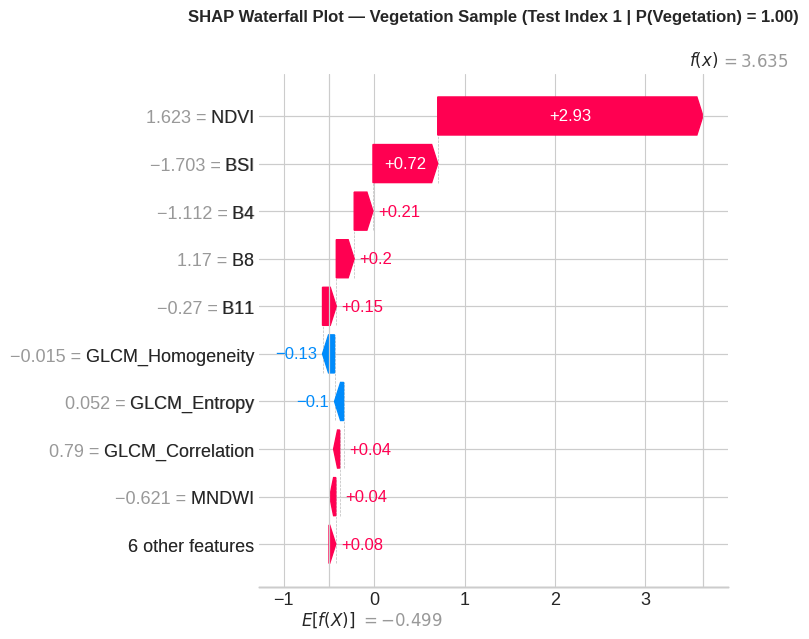

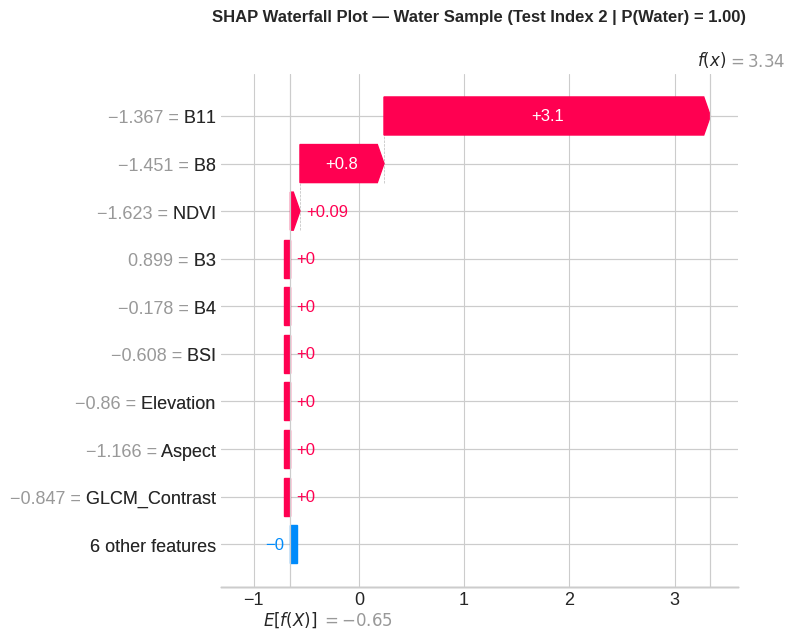

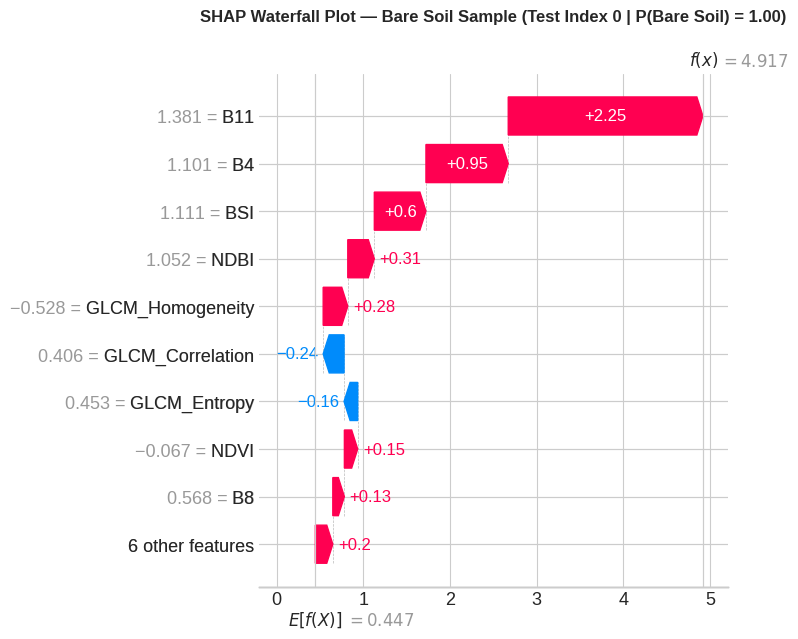

In [ ]:
# ============================================================================
# SHAP WATERFALL PLOTS
# ============================================================================
print(f"\n--- Generating SHAP Waterfall Plots ({TARGET_YEAR}) ---")
y_pred_test = model.predict(X_test)
num_classes = len(target_names)

for cls_idx in range(num_classes):
    cls_name = CLASS_NAMES[cls_idx + 1]
    cls_mask = y_test == cls_idx
    correct_mask = cls_mask & (y_pred_test == cls_idx)

    if np.sum(correct_mask) > 0:
        # Pick the first correctly predicted sample for this class
        sample_idx = np.where(correct_mask)[0][0]

        # Format prediction probability string
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test[sample_idx:sample_idx+1])[0]
            prob_str = f"P({cls_name}) = {probs[cls_idx]:.2f}"
        else:
            prob_str = "Correct Prediction"

        # Compute SHAP explanation object for waterfall plot
        if isinstance(shap_values, list):
            sv_sample = shap_values[cls_idx][sample_idx]
            base_val = explainer.expected_value[cls_idx]
        elif shap_values.ndim == 3:
            sv_sample = shap_values[sample_idx, :, cls_idx]
            base_val = explainer.expected_value[cls_idx]
        else:
            sv_sample = shap_values[sample_idx]
            base_val = explainer.expected_value

        exp = shap.Explanation(
            values=sv_sample,
            base_values=base_val,
            data=X_test[sample_idx],
            feature_names=FEATURE_COLS
        )

        fig = plt.figure(figsize=(10, 6))
        shap.plots.waterfall(exp, show=False)
        plt.title(f'SHAP Waterfall Plot — {cls_name} Sample (Test Index {sample_idx} | {prob_str})', fontsize=12, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.savefig(f'shap_waterfall_{cls_name.lower().replace(" ", "_")}_{TARGET_YEAR}.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
         print(f"No correctly predicted samples found for class {cls_name}.")


In [ ]:
# ============================================================================
# SAVE PIPELINE ARTIFACTS
# ============================================================================
import joblib

# 1. Save the active year's XGBoost model and its corresponding scaler
model_filename = os.path.join(DATA_DIR, f'best_model_{TARGET_YEAR}.joblib')
scaler_filename = os.path.join(DATA_DIR, f'scaler_{TARGET_YEAR}.joblib')

joblib.dump(model, model_filename)
joblib.dump(scaler, scaler_filename)

print(f"✓ Model successfully saved: {os.path.basename(model_filename)}")
print(f"✓ Scaler successfully saved: {os.path.basename(scaler_filename)}")

# 2. Compute and export global SHAP feature importances to CSV
if isinstance(shap_values, list):
    global_importances = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    global_importances = np.abs(shap_values).mean(axis=(0, 2))
else:
    global_importances = np.abs(shap_values).mean(axis=0)

importance_summary_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Mean_Absolute_SHAP': global_importances
}).sort_values('Mean_Absolute_SHAP', ascending=False)

csv_filename = os.path.join(DATA_DIR, f'shap_feature_importance_{TARGET_YEAR}.csv')
importance_summary_df.to_csv(csv_filename, index=False)
print(f"✓ SHAP global feature importances exported to: {os.path.basename(csv_filename)}")


✓ Model successfully saved: best_model_2024.joblib
✓ Scaler successfully saved: scaler_2024.joblib
✓ SHAP global feature importances exported to: shap_feature_importance_2024.csv


In [ ]:
# ============================================================================
# SPATIAL TFRECORD INFERENCE PIPELINE (HARDCODED FOR 2020)
# ============================================================================
# Hardcode configuration for this cell run
TARGET_YEAR = 2020
best_algorithm = 'XGBoost'

# Load the correct model, scaler, and feature set for 2020
model = MODELS[TARGET_YEAR][best_algorithm]
scaler = SPLIT_DATA[TARGET_YEAR]['scaler']
FEATURE_COLS = FEATURE_COLS_MAP[TARGET_YEAR]

try:
    import tensorflow as tf
    TENSORFLOW_AVAILABLE = True
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("Warning: TensorFlow not installed. Spatial predictions skipped.")

if TENSORFLOW_AVAILABLE and RASTERIO_AVAILABLE:
    print(f"\n--- Loading Spatial Datasets ({TARGET_YEAR}) ---")

    TF_DIR = DATA_DIR

    # Match the exact naming convention from your Drive for 2020
    tfrecord_pattern = os.path.join(TF_DIR, f'*_FeatureStack_{TARGET_YEAR}_TFRecord-*.tfrecord*')
    json_pattern = os.path.join(TF_DIR, f'*_FeatureStack_{TARGET_YEAR}_TFRecord*.json')

    tfrecord_files = sorted(glob.glob(tfrecord_pattern))
    json_file = glob.glob(json_pattern)

    if not tfrecord_files or not json_file:
         print(f"⚠ TFRecord shards or JSON metadata file not found at {TF_DIR}!")
         print(f"  Attempted Search Patterns:")
         print(f"    TFRecord: {tfrecord_pattern}")
         print(f"    JSON:     {json_pattern}")
    else:
        json_file = json_file[0]
        output_tiff = os.path.join(DATA_DIR, f'GAMA_LULC_{best_algorithm}_{TARGET_YEAR}.tif')

        print(f"✓ Found JSON Mixer: {os.path.basename(json_file)}")
        print(f"✓ Found {len(tfrecord_files)} TFRecord files.")

        with open(json_file, 'r') as f:
            mixer = json.load(f)

        projection = mixer['projection']
        affine = projection['affine']['doubleMatrix']
        crs = projection['crs']

        patch_cols = mixer['patchDimensions'][0]
        patch_rows = mixer['patchDimensions'][1]
        patches_along_cols = mixer['patchesPerRow']
        total_patches = mixer['totalPatches']

        total_cols = patch_cols * patches_along_cols
        total_rows = patch_rows * (total_patches // patches_along_cols)

        # Retrieve all band names present in TFRecord metadata or fallback to training features
        if 'features' in mixer:
            bands = [b['name'] for b in mixer['features']]
        else:
            bands = list(FEATURE_COLS)

        print(f"Found {len(bands)} bands in TFRecord export.")
        print(f"Image dimensions: {total_cols} x {total_rows} pixels")

        # Build parser description matching exported TFRecord schema
        feature_description = {
            b: tf.io.FixedLenFeature(shape=[patch_rows * patch_cols], dtype=tf.float32)
            for b in bands
        }

        def parse_tfrecord(example_proto):
            return tf.io.parse_single_example(example_proto, feature_description)

        # Determine compression type from file extension
        compression = 'GZIP' if tfrecord_files[0].endswith('.gz') else None
        dataset = tf.data.TFRecordDataset(tfrecord_files, compression_type=compression)
        parsed_dataset = dataset.map(parse_tfrecord)
        prediction_grid = np.zeros((total_rows, total_cols), dtype=np.uint8)

        print("\nPredicting on TFRecord patches...")
        for patch_idx, parsed_patch in enumerate(parsed_dataset):
            col_offset = (patch_idx % patches_along_cols) * patch_cols
            row_offset = (patch_idx // patches_along_cols) * patch_rows
            actual_rows = min(patch_rows, total_rows - row_offset)
            actual_cols = min(patch_cols, total_cols - col_offset)

            # Extract features and stack in training feature order
            features_dict = {b: parsed_patch[b].numpy() for b in FEATURE_COLS}
            pixels = np.stack([features_dict[feat] for feat in FEATURE_COLS], axis=-1)

            # Mask out nodata/empty boundary pixels
            b_mask_name = 'B3' if 'B3' in parsed_patch else bands[0]
            b_mask = parsed_patch[b_mask_name].numpy()
            valid_mask = (b_mask > 0) & (~np.isnan(b_mask))

            predictions = np.zeros(patch_rows * patch_cols, dtype=np.uint8)
            valid_pixels = pixels[valid_mask]

            if len(valid_pixels) > 0:
                # ====== STANDARDIZE PIXELS USING THE LOADED SCALER ======
                scaled_pixels = scaler.transform(valid_pixels)
                preds = model.predict(scaled_pixels) + 1  # Map 0-3 back to 1-4 LULC classes
                predictions[valid_mask] = preds.astype(np.uint8)

            patch_preds_2d = predictions.reshape(patch_rows, patch_cols)
            prediction_grid[
                row_offset:row_offset+actual_rows,
                col_offset:col_offset+actual_cols
            ] = patch_preds_2d[:actual_rows, :actual_cols]

            if (patch_idx + 1) % 150 == 0:
                print(f"  Processed patch {patch_idx + 1}/{total_patches}...")
                gc.collect()

        # Export as geo-referenced GeoTIFF
        transform = rasterio.transform.Affine(
            affine[0], affine[1], affine[2],
            affine[3], affine[4], affine[5]
        )
        out_meta = {
            'driver': 'GTiff',
            'height': total_rows,
            'width': total_cols,
            'count': 1,
            'dtype': 'uint8',
            'crs': crs,
            'transform': transform,
            'nodata': 0,
            'compress': 'deflate'
        }
        with rasterio.open(output_tiff, 'w', **out_meta) as dst:
            dst.write(prediction_grid, 1)
        print(f"\n✓ Seamless classified LULC map saved: {os.path.basename(output_tiff)}")



--- Loading Spatial Datasets (2020) ---
✓ Found JSON Mixer: XAI_LULC_GAMA_FeatureStack_2020_TFRecord-mixer.json
✓ Found 9 TFRecord files.
Found 15 bands in TFRecord export.
Image dimensions: 13440 x 7040 pixels

Predicting on TFRecord patches...
  Processed patch 150/5775...
  Processed patch 300/5775...
  Processed patch 450/5775...
  Processed patch 600/5775...
  Processed patch 750/5775...
  Processed patch 900/5775...
  Processed patch 1050/5775...
  Processed patch 1200/5775...
  Processed patch 1350/5775...
  Processed patch 1500/5775...
  Processed patch 1650/5775...
  Processed patch 1800/5775...
  Processed patch 1950/5775...
  Processed patch 2100/5775...
  Processed patch 2250/5775...
  Processed patch 2400/5775...
  Processed patch 2550/5775...
  Processed patch 2700/5775...
  Processed patch 2850/5775...
  Processed patch 3000/5775...
  Processed patch 3150/5775...
  Processed patch 3300/5775...
  Processed patch 3450/5775...
  Processed patch 3600/5775...
  Processed pat


--- LULC Class Areas (2020 - XGBoost) ---
  Built-Up    : 16,964,456 pixels =  1696.45 km²  (45.4%)
  Vegetation  : 12,938,400 pixels =  1293.84 km²  (34.6%)
  Water       :  1,495,683 pixels =   149.57 km²  (4.0%)
  Bare Soil   :  5,949,056 pixels =   594.91 km²  (15.9%)


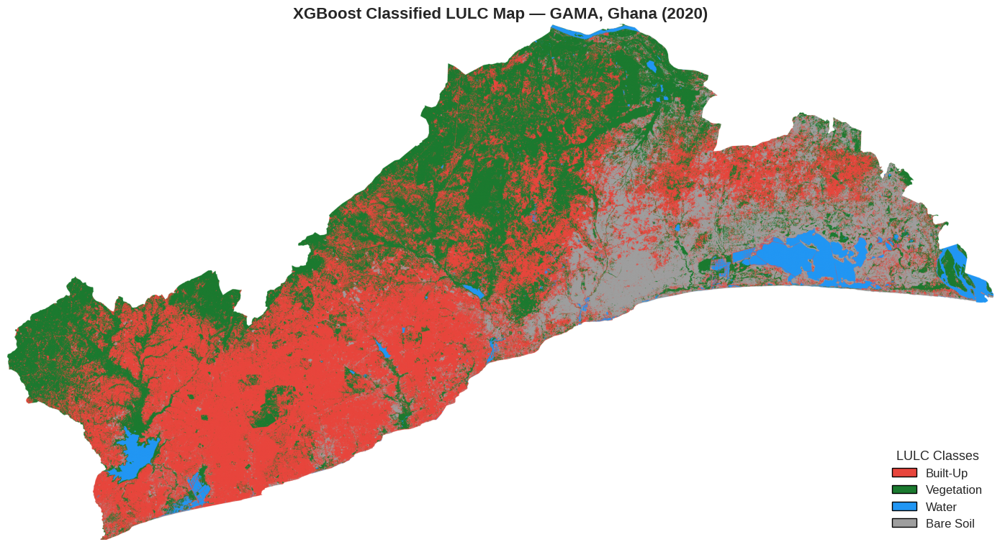

In [ ]:
# ============================================================================
# MAP VISUALIZATION AND AREA CALCULATION (HARDCODED FOR 2020)
# ============================================================================
TARGET_YEAR = 2020
best_algorithm = 'XGBoost'

if RASTERIO_AVAILABLE:
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch

    # White background for nodata (0), color codes for classes 1-4
    map_colors = ['#FFFFFF', '#E8453C', '#1B7A2F', '#2196F3', '#9E9E9E']
    cmap = ListedColormap(map_colors)

    output_tiff = os.path.join(DATA_DIR, f'GAMA_LULC_{best_algorithm}_{TARGET_YEAR}.tif')
    if os.path.exists(output_tiff):
        with rasterio.open(output_tiff) as rst:
            grid = rst.read(1)

        print(f"\n--- LULC Class Areas ({TARGET_YEAR} - {best_algorithm}) ---")
        pixel_area_km2 = (10 * 10) / 1e6  # 10m Sentinel-2 resolution
        valid_pixels = np.sum(grid > 0)

        for cls_id in [1, 2, 3, 4]:
            cls_name = CLASS_NAMES[cls_id]
            pixel_count = np.sum(grid == cls_id)
            area_km2 = pixel_count * pixel_area_km2
            pct = (pixel_count / valid_pixels * 100) if valid_pixels > 0 else 0
            print(f"  {cls_name:12s}: {pixel_count:>10,} pixels = {area_km2:>8.2f} km²  ({pct:.1f}%)")

        fig, ax = plt.subplots(figsize=(14, 12))
        im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=4)
        ax.set_title(f'{best_algorithm} Classified LULC Map — GAMA, Ghana ({TARGET_YEAR})', fontsize=16, fontweight='bold')
        ax.axis('off')

        legend_elements = [
            Patch(facecolor='#E8453C', edgecolor='black', label='Built-Up'),
            Patch(facecolor='#1B7A2F', edgecolor='black', label='Vegetation'),
            Patch(facecolor='#2196F3', edgecolor='black', label='Water'),
            Patch(facecolor='#9E9E9E', edgecolor='black', label='Bare Soil'),
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=12, framealpha=0.9, edgecolor='black', title='LULC Classes', title_fontsize=13)
        plt.tight_layout()
        plt.savefig(f'GAMA_LULC_{best_algorithm}_{TARGET_YEAR}.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"\nClassified map not found at {output_tiff}")


In [ ]:
# ============================================================================
# SPATIAL TFRECORD INFERENCE PIPELINE (HARDCODED FOR 2022)
# ============================================================================
TARGET_YEAR = 2022
best_algorithm = 'XGBoost'

# Load the correct model, scaler, and feature set for 2022
model = MODELS[TARGET_YEAR][best_algorithm]
scaler = SPLIT_DATA[TARGET_YEAR]['scaler']
FEATURE_COLS = FEATURE_COLS_MAP[TARGET_YEAR]

try:
    import tensorflow as tf
    TENSORFLOW_AVAILABLE = True
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("Warning: TensorFlow not installed. Spatial predictions skipped.")

if TENSORFLOW_AVAILABLE and RASTERIO_AVAILABLE:
    print(f"\n--- Loading Spatial Datasets ({TARGET_YEAR}) ---")

    TF_DIR = DATA_DIR

    # Match the exact naming convention from your Drive for 2022
    tfrecord_pattern = os.path.join(TF_DIR, f'*_FeatureStack_{TARGET_YEAR}_TFRecord-*.tfrecord*')
    json_pattern = os.path.join(TF_DIR, f'*_FeatureStack_{TARGET_YEAR}_TFRecord*.json')

    tfrecord_files = sorted(glob.glob(tfrecord_pattern))
    json_file = glob.glob(json_pattern)

    if not tfrecord_files or not json_file:
         print(f"⚠ TFRecord shards or JSON metadata file not found at {TF_DIR}!")
         print(f"  Attempted Search Patterns:")
         print(f"    TFRecord: {tfrecord_pattern}")
         print(f"    JSON:     {json_pattern}")
    else:
        json_file = json_file[0]
        output_tiff = os.path.join(DATA_DIR, f'GAMA_LULC_{best_algorithm}_{TARGET_YEAR}.tif')

        print(f"✓ Found JSON Mixer: {os.path.basename(json_file)}")
        print(f"✓ Found {len(tfrecord_files)} TFRecord files.")

        with open(json_file, 'r') as f:
            mixer = json.load(f)

        projection = mixer['projection']
        affine = projection['affine']['doubleMatrix']
        crs = projection['crs']

        patch_cols = mixer['patchDimensions'][0]
        patch_rows = mixer['patchDimensions'][1]
        patches_along_cols = mixer['patchesPerRow']
        total_patches = mixer['totalPatches']

        total_cols = patch_cols * patches_along_cols
        total_rows = patch_rows * (total_patches // patches_along_cols)

        # Retrieve all band names present in TFRecord metadata or fallback to training features
        if 'features' in mixer:
            bands = [b['name'] for b in mixer['features']]
        else:
            bands = list(FEATURE_COLS)

        print(f"Found {len(bands)} bands in TFRecord export.")
        print(f"Image dimensions: {total_cols} x {total_rows} pixels")

        # Build parser description matching exported TFRecord schema
        feature_description = {
            b: tf.io.FixedLenFeature(shape=[patch_rows * patch_cols], dtype=tf.float32)
            for b in bands
        }

        def parse_tfrecord(example_proto):
            return tf.io.parse_single_example(example_proto, feature_description)

        # Determine compression type from file extension
        compression = 'GZIP' if tfrecord_files[0].endswith('.gz') else None
        dataset = tf.data.TFRecordDataset(tfrecord_files, compression_type=compression)
        parsed_dataset = dataset.map(parse_tfrecord)
        prediction_grid = np.zeros((total_rows, total_cols), dtype=np.uint8)

        print("\nPredicting on TFRecord patches...")
        for patch_idx, parsed_patch in enumerate(parsed_dataset):
            col_offset = (patch_idx % patches_along_cols) * patch_cols
            row_offset = (patch_idx // patches_along_cols) * patch_rows
            actual_rows = min(patch_rows, total_rows - row_offset)
            actual_cols = min(patch_cols, total_cols - col_offset)

            # Extract features and stack in training feature order
            features_dict = {b: parsed_patch[b].numpy() for b in FEATURE_COLS}
            pixels = np.stack([features_dict[feat] for feat in FEATURE_COLS], axis=-1)

            # Mask out nodata/empty boundary pixels
            b_mask_name = 'B3' if 'B3' in parsed_patch else bands[0]
            b_mask = parsed_patch[b_mask_name].numpy()
            valid_mask = (b_mask > 0) & (~np.isnan(b_mask))

            predictions = np.zeros(patch_rows * patch_cols, dtype=np.uint8)
            valid_pixels = pixels[valid_mask]

            if len(valid_pixels) > 0:
                # ====== STANDARDIZE PIXELS USING THE LOADED SCALER ======
                scaled_pixels = scaler.transform(valid_pixels)
                preds = model.predict(scaled_pixels) + 1  # Map 0-3 back to 1-4 LULC classes
                predictions[valid_mask] = preds.astype(np.uint8)

            patch_preds_2d = predictions.reshape(patch_rows, patch_cols)
            prediction_grid[
                row_offset:row_offset+actual_rows,
                col_offset:col_offset+actual_cols
            ] = patch_preds_2d[:actual_rows, :actual_cols]

            if (patch_idx + 1) % 150 == 0:
                print(f"  Processed patch {patch_idx + 1}/{total_patches}...")
                gc.collect()

        # Export as geo-referenced GeoTIFF
        transform = rasterio.transform.Affine(
            affine[0], affine[1], affine[2],
            affine[3], affine[4], affine[5]
        )
        out_meta = {
            'driver': 'GTiff',
            'height': total_rows,
            'width': total_cols,
            'count': 1,
            'dtype': 'uint8',
            'crs': crs,
            'transform': transform,
            'nodata': 0,
            'compress': 'deflate'
        }
        with rasterio.open(output_tiff, 'w', **out_meta) as dst:
            dst.write(prediction_grid, 1)
        print(f"\n✓ Seamless classified LULC map saved: {os.path.basename(output_tiff)}")



--- Loading Spatial Datasets (2022) ---
✓ Found JSON Mixer: XAI_LULC_GAMA_FeatureStack_2022_TFRecord-mixer.json
✓ Found 9 TFRecord files.
Found 15 bands in TFRecord export.
Image dimensions: 13440 x 7040 pixels

Predicting on TFRecord patches...
  Processed patch 150/5775...
  Processed patch 300/5775...
  Processed patch 450/5775...
  Processed patch 600/5775...
  Processed patch 750/5775...
  Processed patch 900/5775...
  Processed patch 1050/5775...
  Processed patch 1200/5775...
  Processed patch 1350/5775...
  Processed patch 1500/5775...
  Processed patch 1650/5775...
  Processed patch 1800/5775...
  Processed patch 1950/5775...
  Processed patch 2100/5775...
  Processed patch 2250/5775...
  Processed patch 2400/5775...
  Processed patch 2550/5775...
  Processed patch 2700/5775...
  Processed patch 2850/5775...
  Processed patch 3000/5775...
  Processed patch 3150/5775...
  Processed patch 3300/5775...
  Processed patch 3450/5775...
  Processed patch 3600/5775...
  Processed pat


--- LULC Class Areas (2022 - XGBoost) ---
  Built-Up    : 18,487,113 pixels =  1848.71 km²  (49.5%)
  Vegetation  : 11,851,723 pixels =  1185.17 km²  (31.7%)
  Water       :  2,712,626 pixels =   271.26 km²  (7.3%)
  Bare Soil   :  4,296,129 pixels =   429.61 km²  (11.5%)


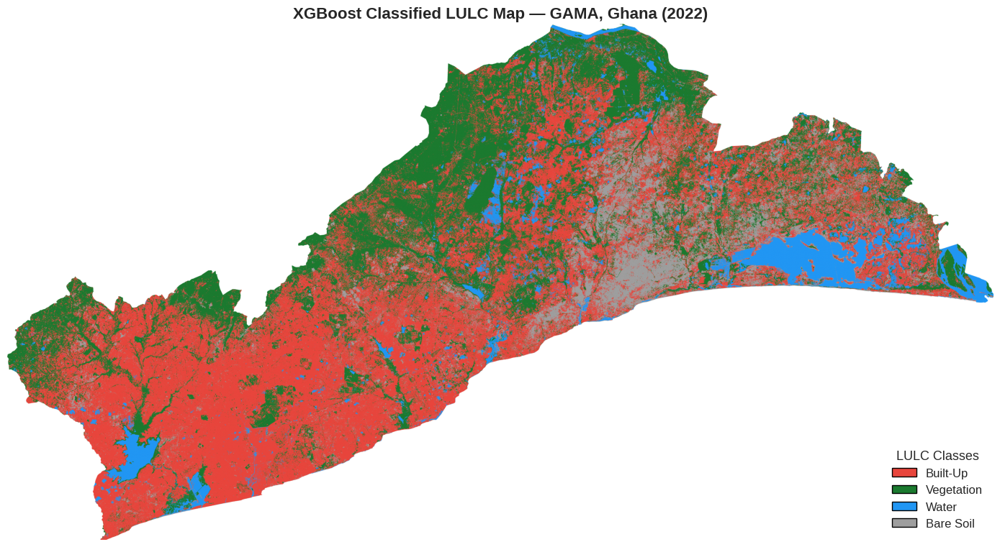

In [ ]:
# ============================================================================
# MAP VISUALIZATION AND AREA CALCULATION (HARDCODED FOR 2022)
# ============================================================================
TARGET_YEAR = 2022
best_algorithm = 'XGBoost'

if RASTERIO_AVAILABLE:
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch

    # White background for nodata (0), color codes for classes 1-4
    map_colors = ['#FFFFFF', '#E8453C', '#1B7A2F', '#2196F3', '#9E9E9E']
    cmap = ListedColormap(map_colors)

    output_tiff = os.path.join(DATA_DIR, f'GAMA_LULC_{best_algorithm}_{TARGET_YEAR}.tif')
    if os.path.exists(output_tiff):
        with rasterio.open(output_tiff) as rst:
            grid = rst.read(1)

        print(f"\n--- LULC Class Areas ({TARGET_YEAR} - {best_algorithm}) ---")
        pixel_area_km2 = (10 * 10) / 1e6  # 10m Sentinel-2 resolution
        valid_pixels = np.sum(grid > 0)

        for cls_id in [1, 2, 3, 4]:
            cls_name = CLASS_NAMES[cls_id]
            pixel_count = np.sum(grid == cls_id)
            area_km2 = pixel_count * pixel_area_km2
            pct = (pixel_count / valid_pixels * 100) if valid_pixels > 0 else 0
            print(f"  {cls_name:12s}: {pixel_count:>10,} pixels = {area_km2:>8.2f} km²  ({pct:.1f}%)")

        fig, ax = plt.subplots(figsize=(14, 12))
        im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=4)
        ax.set_title(f'{best_algorithm} Classified LULC Map — GAMA, Ghana ({TARGET_YEAR})', fontsize=16, fontweight='bold')
        ax.axis('off')

        legend_elements = [
            Patch(facecolor='#E8453C', edgecolor='black', label='Built-Up'),
            Patch(facecolor='#1B7A2F', edgecolor='black', label='Vegetation'),
            Patch(facecolor='#2196F3', edgecolor='black', label='Water'),
            Patch(facecolor='#9E9E9E', edgecolor='black', label='Bare Soil'),
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=12, framealpha=0.9, edgecolor='black', title='LULC Classes', title_fontsize=13)
        plt.tight_layout()
        plt.savefig(f'GAMA_LULC_{best_algorithm}_{TARGET_YEAR}.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"\nClassified map not found at {output_tiff}")


In [ ]:
# ============================================================================
# SPATIAL TFRECORD INFERENCE PIPELINE (HARDCODED FOR 2024)
# ============================================================================
TARGET_YEAR = 2024
best_algorithm = 'XGBoost'

# Load the correct model, scaler, and feature set for 2024
model = MODELS[TARGET_YEAR][best_algorithm]
scaler = SPLIT_DATA[TARGET_YEAR]['scaler']
FEATURE_COLS = FEATURE_COLS_MAP[TARGET_YEAR]

try:
    import tensorflow as tf
    TENSORFLOW_AVAILABLE = True
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("Warning: TensorFlow not installed. Spatial predictions skipped.")

if TENSORFLOW_AVAILABLE and RASTERIO_AVAILABLE:
    print(f"\n--- Loading Spatial Datasets ({TARGET_YEAR}) ---")

    TF_DIR = DATA_DIR

    # Match the exact naming convention from your Drive for 2024
    tfrecord_pattern = os.path.join(TF_DIR, f'*_FeatureStack_{TARGET_YEAR}_TFRecord-*.tfrecord*')
    json_pattern = os.path.join(TF_DIR, f'*_FeatureStack_{TARGET_YEAR}_TFRecord*.json')

    tfrecord_files = sorted(glob.glob(tfrecord_pattern))
    json_file = glob.glob(json_pattern)

    if not tfrecord_files or not json_file:
         print(f"⚠ TFRecord shards or JSON metadata file not found at {TF_DIR}!")
         print(f"  Attempted Search Patterns:")
         print(f"    TFRecord: {tfrecord_pattern}")
         print(f"    JSON:     {json_pattern}")
    else:
        json_file = json_file[0]
        output_tiff = os.path.join(DATA_DIR, f'GAMA_LULC_{best_algorithm}_{TARGET_YEAR}.tif')

        print(f"✓ Found JSON Mixer: {os.path.basename(json_file)}")
        print(f"✓ Found {len(tfrecord_files)} TFRecord files.")

        with open(json_file, 'r') as f:
            mixer = json.load(f)

        projection = mixer['projection']
        affine = projection['affine']['doubleMatrix']
        crs = projection['crs']

        patch_cols = mixer['patchDimensions'][0]
        patch_rows = mixer['patchDimensions'][1]
        patches_along_cols = mixer['patchesPerRow']
        total_patches = mixer['totalPatches']

        total_cols = patch_cols * patches_along_cols
        total_rows = patch_rows * (total_patches // patches_along_cols)

        # Retrieve all band names present in TFRecord metadata or fallback to training features
        if 'features' in mixer:
            bands = [b['name'] for b in mixer['features']]
        else:
            bands = list(FEATURE_COLS)

        print(f"Found {len(bands)} bands in TFRecord export.")
        print(f"Image dimensions: {total_cols} x {total_rows} pixels")

        # Build parser description matching exported TFRecord schema
        feature_description = {
            b: tf.io.FixedLenFeature(shape=[patch_rows * patch_cols], dtype=tf.float32)
            for b in bands
        }

        def parse_tfrecord(example_proto):
            return tf.io.parse_single_example(example_proto, feature_description)

        # Determine compression type from file extension
        compression = 'GZIP' if tfrecord_files[0].endswith('.gz') else None
        dataset = tf.data.TFRecordDataset(tfrecord_files, compression_type=compression)
        parsed_dataset = dataset.map(parse_tfrecord)
        prediction_grid = np.zeros((total_rows, total_cols), dtype=np.uint8)

        print("\nPredicting on TFRecord patches...")
        for patch_idx, parsed_patch in enumerate(parsed_dataset):
            col_offset = (patch_idx % patches_along_cols) * patch_cols
            row_offset = (patch_idx // patches_along_cols) * patch_rows
            actual_rows = min(patch_rows, total_rows - row_offset)
            actual_cols = min(patch_cols, total_cols - col_offset)

            # Extract features and stack in training feature order
            features_dict = {b: parsed_patch[b].numpy() for b in FEATURE_COLS}
            pixels = np.stack([features_dict[feat] for feat in FEATURE_COLS], axis=-1)

            # Mask out nodata/empty boundary pixels
            b_mask_name = 'B3' if 'B3' in parsed_patch else bands[0]
            b_mask = parsed_patch[b_mask_name].numpy()
            valid_mask = (b_mask > 0) & (~np.isnan(b_mask))

            predictions = np.zeros(patch_rows * patch_cols, dtype=np.uint8)
            valid_pixels = pixels[valid_mask]

            if len(valid_pixels) > 0:
                # ====== STANDARDIZE PIXELS USING THE LOADED SCALER ======
                scaled_pixels = scaler.transform(valid_pixels)
                preds = model.predict(scaled_pixels) + 1  # Map 0-3 back to 1-4 LULC classes
                predictions[valid_mask] = preds.astype(np.uint8)

            patch_preds_2d = predictions.reshape(patch_rows, patch_cols)
            prediction_grid[
                row_offset:row_offset+actual_rows,
                col_offset:col_offset+actual_cols
            ] = patch_preds_2d[:actual_rows, :actual_cols]

            if (patch_idx + 1) % 150 == 0:
                print(f"  Processed patch {patch_idx + 1}/{total_patches}...")
                gc.collect()

        # Export as geo-referenced GeoTIFF
        transform = rasterio.transform.Affine(
            affine[0], affine[1], affine[2],
            affine[3], affine[4], affine[5]
        )
        out_meta = {
            'driver': 'GTiff',
            'height': total_rows,
            'width': total_cols,
            'count': 1,
            'dtype': 'uint8',
            'crs': crs,
            'transform': transform,
            'nodata': 0,
            'compress': 'deflate'
        }
        with rasterio.open(output_tiff, 'w', **out_meta) as dst:
            dst.write(prediction_grid, 1)
        print(f"\n✓ Seamless classified LULC map saved: {os.path.basename(output_tiff)}")



--- Loading Spatial Datasets (2024) ---
✓ Found JSON Mixer: XAI_LULC_GAMA_FeatureStack_2024_TFRecord-mixer.json
✓ Found 9 TFRecord files.
Found 15 bands in TFRecord export.
Image dimensions: 13440 x 7040 pixels

Predicting on TFRecord patches...
  Processed patch 150/5775...
  Processed patch 300/5775...
  Processed patch 450/5775...
  Processed patch 600/5775...
  Processed patch 750/5775...
  Processed patch 900/5775...
  Processed patch 1050/5775...
  Processed patch 1200/5775...
  Processed patch 1350/5775...
  Processed patch 1500/5775...
  Processed patch 1650/5775...
  Processed patch 1800/5775...
  Processed patch 1950/5775...
  Processed patch 2100/5775...
  Processed patch 2250/5775...
  Processed patch 2400/5775...
  Processed patch 2550/5775...
  Processed patch 2700/5775...
  Processed patch 2850/5775...
  Processed patch 3000/5775...
  Processed patch 3150/5775...
  Processed patch 3300/5775...
  Processed patch 3450/5775...
  Processed patch 3600/5775...
  Processed pat


--- LULC Class Areas (2024 - XGBoost) ---
  Built-Up    : 22,298,131 pixels =  2229.81 km²  (59.7%)
  Vegetation  :  8,175,297 pixels =   817.53 km²  (21.9%)
  Water       :  1,529,044 pixels =   152.90 km²  (4.1%)
  Bare Soil   :  5,345,123 pixels =   534.51 km²  (14.3%)


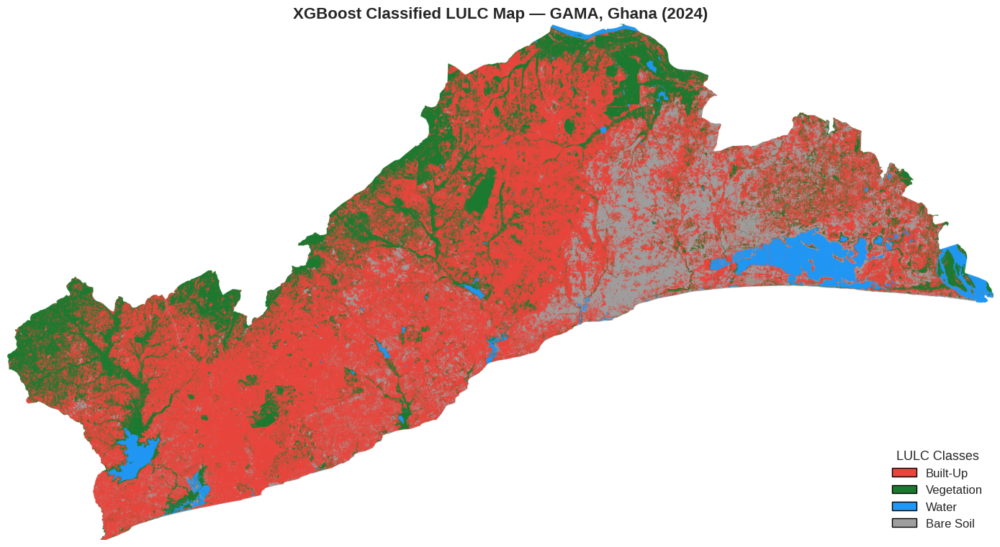

In [ ]:
# ============================================================================
# MAP VISUALIZATION AND AREA CALCULATION (HARDCODED FOR 2024)
# ============================================================================
TARGET_YEAR = 2024
best_algorithm = 'XGBoost'

if RASTERIO_AVAILABLE:
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch

    # White background for nodata (0), color codes for classes 1-4
    map_colors = ['#FFFFFF', '#E8453C', '#1B7A2F', '#2196F3', '#9E9E9E']
    cmap = ListedColormap(map_colors)

    output_tiff = os.path.join(DATA_DIR, f'GAMA_LULC_{best_algorithm}_{TARGET_YEAR}.tif')
    if os.path.exists(output_tiff):
        with rasterio.open(output_tiff) as rst:
            grid = rst.read(1)

        print(f"\n--- LULC Class Areas ({TARGET_YEAR} - {best_algorithm}) ---")
        pixel_area_km2 = (10 * 10) / 1e6  # 10m Sentinel-2 resolution
        valid_pixels = np.sum(grid > 0)

        for cls_id in [1, 2, 3, 4]:
            cls_name = CLASS_NAMES[cls_id]
            pixel_count = np.sum(grid == cls_id)
            area_km2 = pixel_count * pixel_area_km2
            pct = (pixel_count / valid_pixels * 100) if valid_pixels > 0 else 0
            print(f"  {cls_name:12s}: {pixel_count:>10,} pixels = {area_km2:>8.2f} km²  ({pct:.1f}%)")

        fig, ax = plt.subplots(figsize=(14, 12))
        im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=4)
        ax.set_title(f'{best_algorithm} Classified LULC Map — GAMA, Ghana ({TARGET_YEAR})', fontsize=16, fontweight='bold')
        ax.axis('off')

        legend_elements = [
            Patch(facecolor='#E8453C', edgecolor='black', label='Built-Up'),
            Patch(facecolor='#1B7A2F', edgecolor='black', label='Vegetation'),
            Patch(facecolor='#2196F3', edgecolor='black', label='Water'),
            Patch(facecolor='#9E9E9E', edgecolor='black', label='Bare Soil'),
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=12, framealpha=0.9, edgecolor='black', title='LULC Classes', title_fontsize=13)
        plt.tight_layout()
        plt.savefig(f'GAMA_LULC_{best_algorithm}_{TARGET_YEAR}.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"\nClassified map not found at {output_tiff}")
